## Bayesian Modelling of River Flow Anomaly Detection Accounting for Physical-Geographic Features in the Vistula Basin

Paweł Jerzyna, Piotr Grzyb

In [2]:
import os
import sys
import glob
import re
from pathlib import Path
import folium
import xarray as xr
import pickle
import json

from cmdstanpy import CmdStanModel

import arviz as az
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.getcwd())
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

DATASET_DIR = PROJECT_ROOT / "dataset"
DATASET_DIR_CLEAN = PROJECT_ROOT / "cleaned_dataset"
DATASET_DIR_TXT = DATASET_DIR_CLEAN / "txt_files"
DATASET_DIR_CSV = DATASET_DIR_CLEAN / "csv_files"

sys.path.append(str(PROJECT_ROOT))

/home/pawsooon/miniconda3/envs/data_analytics/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Czyszczenie danych: Ekstrakcja lat 2023-2025 z surowego datasetu do folderu dataset_cleaned

In [2]:
def clean_grdc_file(file_path, output_path):
    metadata = {
        "River": "Nieznana",
        "Station": "Nieznana",
        "Country": "Nieznany",
        "Latitude": "-999.000",
        "Longitude": "-999.000",
        "Catchment": "-999.00",
        "Altitude": "-999.00"
    }
    
    data_lines = []
    
    # Odczyt w kodowaniu 'latin-1' chroni przed błędem crashowania na jednostkach typu km²
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for i, line in enumerate(lines):
        stripped = line.strip()
        
        # Przetwarzanie linii nagłówkowych
        if stripped.startswith('#'):
            content = stripped[1:].strip()
            
            if "River:" in content:
                metadata["River"] = content.split("River:")[1].strip()
            elif "Station:" in content:
                metadata["Station"] = content.split("Station:")[1].strip()
            elif "Country:" in content:
                metadata["Country"] = content.split("Country:")[1].strip()
            elif "Latitude (DD):" in content:
                metadata["Latitude"] = content.split("Latitude (DD):")[1].strip()
            elif "Longitude (DD):" in content:
                metadata["Longitude"] = content.split("Longitude (DD):")[1].strip()
            elif "Catchment area" in content:
                val = content.split(":")[-1].strip()
                if not val and i + 1 < len(lines):
                    next_line = lines[i+1].strip()
                    if next_line.startswith('#'):
                        next_line = next_line[1:].strip()
                    if next_line and ';' not in next_line:
                        val = next_line
                metadata["Catchment"] = val if val else "-999.00"
            elif "Altitude (m ASL):" in content:
                metadata["Altitude"] = content.split("Altitude (m ASL):")[1].strip()
                
        # Przetwarzanie linii z pomiarami
        else:
            if ';' in stripped and not stripped.startswith('YYYY'):
                parts = stripped.split(';')
                if parts:
                    date_part = parts[0].strip()
                    try:
                        # Wyciągamy rok i filtrujemy pod kątem lat 2023, 2024, 2025
                        year = int(date_part.split('-')[0])
                        if year in [2023, 2024, 2025]:
                            data_lines.append(line.rstrip())
                    except (ValueError, IndexError):
                        pass

    # Jeśli stacja nie posiada danych z lat 2023-2025, nie generujemy pliku wyjściowego
    if not data_lines:
        return False
    
    # Budowanie struktury pliku tekstowego z zachowaniem idealnego wyrównania spacji
    output_lines = [
        f"River: {metadata['River']}",
        f"Station: {metadata['Station']}",
        f"Country: {metadata['Country']}",
        f"Latitude (DD):       {metadata['Latitude']}",
        f"Longitude (DD):      {metadata['Longitude']}",
        f"Catchment area (km²):      {metadata['Catchment']}",
        f"Altitude (m ASL):        {metadata['Altitude']}",
        "" # Pusta linia oddzielająca metadane od danych
    ]
    
    output_lines.extend(data_lines)
    
    # Zapis w bezpiecznym standardzie UTF-8
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(output_lines) + '\n')
        
    return True

# SZTYWNE USTAWIENIE ŚCIEŻEK - ODPORNE NA CONFIG Z INNYCH KOMÓREK
input_folder = PROJECT_ROOT / "dataset"
output_folder = PROJECT_ROOT / "dataset_cleaned"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje!")
else:
    # Tworzenie nowego folderu docelowego
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików pomijając pliki geojson lub inne śmieciowe
    all_files = [f for f in input_folder.glob('*') if f.is_file() and f.suffix != '.geojson']
    
    print(f"🚀 Rozpoczynam przetwarzanie... Znaleziono {len(all_files)} plików w folderze '{input_folder.name}'.")
    
    success = 0
    skipped = 0
    
    for file_path in all_files:
        # Zapis pod dokładnie taką samą nazwą pliku w nowym katalogu
        output_path = output_folder / file_path.name
        
        try:
            was_written = clean_grdc_file(file_path, output_path)
            if was_written:
                success += 1
            else:
                skipped += 1
        except Exception as e:
            print(f" -> Błąd w pliku {file_path.name}: {str(e)}")
            
    print("\n" + "="*50)
    print(f"✅ Sukces! Oczyszczono i zapisano: {success} plików.")
    print(f"ℹ️ Pominięto starych stacji:       {skipped} plików.")
    print(f"📁 Wyniki znajdziesz w folderze:    '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam przetwarzanie... Znaleziono 85 plików w folderze 'dataset'.

✅ Sukces! Oczyszczono i zapisano: 69 plików.
ℹ️ Pominięto starych stacji:       16 plików.
📁 Wyniki znajdziesz w folderze:    '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned'


## Czyszczenie danych: Krok 2 – Konwersja wyekstrahowanych plików TXT do płaskich tabel CSV (Oryginalne nazwy)

In [3]:
# Sztywne ustawienie ścieżek wejścia i wyjścia – niezależne od innych komórek
input_folder = PROJECT_ROOT / "dataset_cleaned"
output_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje! Upewnij się, że najpierw uruchomiłeś poprzednią komórkę.")
else:
    # Tworzymy nowy folder na pliki CSV
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików tekstowych z folderu wyekstrahowanego
    files = [f for f in input_folder.glob('*') if f.is_file()]
    
    print(f"🚀 Rozpoczynam konwersję {len(files)} wyekstrahowanych plików TXT do formatu CSV...")
    
    success_count = 0
    error_count = 0
    
    for file_path in files:
        # Generujemy nową nazwę pliku z rozszerzeniem .csv (np. 6258250_Q_Day.Cmd.csv)
        csv_name = file_path.stem + '.csv'
        output_csv_path = output_folder / csv_name
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                
            metadata = {}
            data_lines = []
            is_data = False
            
            # 1. Parsowanie struktury nagłówków tekstowych i wyodrębnienie linii danych
            for line in lines:
                if ":" in line and not is_data and ";" not in line:
                    key, val = line.split(":", 1)
                    metadata[key.strip()] = val.strip()
                else:
                    is_data = True
                    if ';' in line:
                        data_lines.append(line)
            
            parsed_rows = []
            
            # 2. Przetwarzanie rekordów i budowanie płaskiej struktury tabeli (metadane w każdym wierszu)
            for d_line in data_lines:
                parts = d_line.split(';')
                if len(parts) >= 3:
                    date = parts[0].strip()
                    time = parts[1].strip()
                    value = parts[2].strip()
                    
                    parsed_rows.append({
                        "River": metadata.get("River", "Nieznana"),
                        "Station": metadata.get("Station", "Nieznana"),
                        "Country": metadata.get("Country", "Nieznany"),
                        "Latitude_DD": metadata.get("Latitude (DD)", "-999.000"),
                        "Longitude_DD": metadata.get("Longitude (DD)", "-999.000"),
                        "Catchment_area_km2": metadata.get("Catchment area (km²)", "-999.00"),
                        "Altitude_m_ASL": metadata.get("Altitude (m ASL)", "-999.00"),
                        "Date": date,
                        "Time": time,
                        "Value": value
                    })
            
            # Zapisujemy do CSV – dane są już przefiltrowane, więc bierzemy cały wyekstrahowany pakiet
            if parsed_rows:
                df = pd.DataFrame(parsed_rows)
                df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
                success_count += 1
                
        except Exception as e:
            print(f" -> Błąd podczas konwersji pliku {file_path.name}: {str(e)}")
            error_count += 1

    # Końcowy raport operacji
    print("\n" + "="*50)
    print("📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:")
    print(f"   • Konwersja udana (utworzono plików CSV): {success_count}")
    print(f"   • Błędy przetwarzania:                    {error_count}")
    print(f"📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam konwersję 69 wyekstrahowanych plików TXT do formatu CSV...

📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:
   • Konwersja udana (utworzono plików CSV): 69
   • Błędy przetwarzania:                    0
📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned_csv'


## Czyszczenie danych: Krok 3 – Zmiana nazw plików CSV w miejscu (STACJA_RZEKA.csv)

In [4]:
def sanitize_filename(name):
    """Funkcja zamieniająca spacje na myślniki i usuwająca znaki niedozwolone w nazwach plików"""
    if not name or pd.isna(name):
        return "UNKNOWN"
    name = str(name).strip().replace(' ', '-')
    name = re.sub(r'[\\/*?:"<>|]', '', name)
    return name.upper()

# Sztywne ustawienie folderu docelowego - dokładnie tego, który powstał w Kroku 2
target_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not target_folder.exists():
    print(f"❌ Błąd: Folder z plikami CSV '{target_folder}' nie istnieje! Upewnij się, że poprzednia komórka wykonała się poprawnie.")
else:
    # Zczytujemy listę plików do pamięci jako listę obiektów Path, 
    # aby zmiana nazw w locie nie zaburzyła działania pętli (.glob)
    csv_files = [f for f in target_folder.glob('*.csv') if f.is_file()]
    
    print(f"🔄 Rozpoczynam zmianę nazw dla {len(csv_files)} plików CSV w folderze '{target_folder.name}'...")
    
    renamed_count = 0
    already_correct_count = 0
    skipped_count = 0
    error_count = 0
    
    for file_path in csv_files:
        try:
            # Czytamy tylko pierwszy wiersz pliku CSV, żeby wyciągnąć metadane (szybkie i oszczędne)
            df_head = pd.read_csv(file_path, nrows=1)
            
            if df_head.empty or 'Station' not in df_head.columns or 'River' not in df_head.columns:
                print(f"⚠️ Pomijam {file_path.name} - brak wymaganych kolumn 'Station' lub 'River'.")
                skipped_count += 1
                continue
            
            # Wyciągamy wartości z pierwszego wiersza
            station_raw = df_head['Station'].iloc[0]
            river_raw = df_head['River'].iloc[0]
            
            # Czyszczenie nazw stacji i rzek
            station_clean = sanitize_filename(station_raw)
            river_clean = sanitize_filename(river_raw)
            
            # Budujemy nową nazwę pliku
            new_name = f"{station_clean}_{river_clean}.csv"
            new_path = target_folder / new_name
            
            # Jeśli nazwa różni się od obecnej, zmieniamy ją fizycznie na dysku
            if file_path != new_path:
                # Zabezpieczenie: jeśli plik o takiej nazwie docelowej już istnieje, usuwamy go przed nadpisaniem
                if new_path.exists():
                    os.remove(new_path)
                
                # Zmiana nazwy w miejscu
                file_path.rename(new_path)
                print(f"✅ Zmieniono: {file_path.name} ➡️ {new_name}")
                renamed_count += 1
            else:
                already_correct_count += 1
                
        except Exception as e:
            print(f"❌ Błąd podczas przetwarzania {file_path.name}: {str(e)}")
            error_count += 1

    print("\n" + "="*50)
    print("📊 PODSUMOWANIE ZMIANY NAZW IN-PLACE:")
    print(f"   • Zmieniono nazw plików:         {renamed_count}")
    print(f"   • Pliki już poprawnie nazwane:   {already_correct_count}")
    print(f"   • Pominięto (błędna struktura):  {skipped_count}")
    print(f"   • Błędy wykonania:               {error_count}")
    print(f"📁 Wszystkie zaktualizowane pliki są w: '{target_folder}'")
    print("="*50)

🔄 Rozpoczynam zmianę nazw dla 138 plików CSV w folderze 'dataset_cleaned_csv'...
✅ Zmieniono: 6458090_Q_Day.Cmd.csv ➡️ PULAWY-AZOTY_VISTULA.csv
✅ Zmieniono: 6458130_Q_Day.Cmd.csv ➡️ WARSZAWA-NADWILANOWKA_VISTULA.csv
✅ Zmieniono: 6458420_Q_Day.Cmd.csv ➡️ WISLA_VISTULA.csv
✅ Zmieniono: 6458135_Q_Day.Cmd.csv ➡️ ZAMBSKI-KOSCIELNE_NAREV.csv
✅ Zmieniono: 6458030_Q_Day.Cmd.csv ➡️ JELEN_PRZEMSZA.csv
✅ Zmieniono: 6458025_Q_Day.Cmd.csv ➡️ PRZEMYSL_SAN.csv
✅ Zmieniono: 6458200_Q_Day.Cmd.csv ➡️ JORDANOW_SKAWA.csv
✅ Zmieniono: 6458525_Q_Day.Cmd.csv ➡️ NIETULISKO-DUZE_SWISLINA.csv
✅ Zmieniono: 6458809_Q_Day.Cmd.csv ➡️ MYSZYNIEC_ROZOGA.csv
✅ Zmieniono: 6458165_Q_Day.Cmd.csv ➡️ STREKOWA-GORA_NAREV.csv
✅ Zmieniono: 6458020_Q_Day.Cmd.csv ➡️ STARY-SACZ_POPRAD.csv
✅ Zmieniono: 6458620_Q_Day.Cmd.csv ➡️ CISNA_SOLINKA.csv
✅ Zmieniono: 6458120_Q_Day.Cmd.csv ➡️ MODLIN_VISTULA.csv
✅ Zmieniono: 6458150_Q_Day.Cmd.csv ➡️ DOBRYLAS_PISA.csv
✅ Zmieniono: 6458055_Q_Day.Cmd.csv ➡️ MIELEC-2_WISLOKA.csv
✅ Zmieniono: 6458

## Wizualizacja stacji: Punkty pomiarowe na mapie Polski

In [26]:
csv_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not csv_folder.exists():
    print("❌ Błąd: Folder z plikami CSV nie istnieje!")
else:
    csv_files = list(csv_folder.glob('*.csv'))
    
    # Tworzymy bazową mapę wyśrodkowaną na Polskę
    # tiles='OpenStreetMap' pobiera kafelki mapy automatycznie z sieci
    m = folium.Map(location=[52.0, 19.1], zoom_start=6, tiles='OpenStreetMap')
    
    counter = 0
    for file_path in csv_files:
        try:
            df_head = pd.read_csv(file_path, nrows=1)
            lat = float(df_head['Latitude_DD'].iloc[0])
            lon = float(df_head['Longitude_DD'].iloc[0])
            station = df_head['Station'].iloc[0]
            river = df_head['River'].iloc[0]
            country = df_head['Country'].iloc[0]
            
            if lat != -999.000 and lon != -999.000:
                # Treść dymka po kliknięciu w punkt
                popup_text = f"<b>Stacja:</b> {station}<br><b>Rzeka:</b> {river}<br><b>Kraj:</b> {country}"
                
                # Dodajemy punkt na mapę
                folium.Marker(
                    location=[lat, lon],
                    popup=folium.Popup(popup_text, max_width=300),
                    tooltip=f"{station} ({river})",
                    icon=folium.Icon(color='blue', icon='info-sign')
                ).add_to(m)
                
                counter += 1
        except Exception as e:
            pass

    print(f"📊 Załadowano {counter} stacji. Wyświetlam interaktywną mapę...")
    # Wyświetlenie mapy bezpośrednio w Jupyter Notebook
    
    # NAPRAWIC !!!
    display(m)

    # Zapisuje mapę jako autonomiczny plik HTML w Twoim folderze projektu
    m.save("mapa_stacji.html")
    print("🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).")


📊 Załadowano 69 stacji. Wyświetlam interaktywną mapę...


🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).


# Konkatenacja wyczyszczonych danych w dataframe i filtrowanie

In [14]:
# Define directory containing CSV files
csv_folder = Path("dataset_cleaned_csv") 

# Initialize empty list to store dataframes
df_list = []

# Iterate through all CSV files
for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    
    # Format dates and handle missing values
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Value'] = temp_df['Value'].replace(-999.000, pd.NA)
    
    df_list.append(temp_df)

# Concatenate into a single long-format dataframe
df = pd.concat(df_list, ignore_index=True)

# Remove rows with missing flow values
df = df.dropna(subset=['Value'])

# Verify structure
print(df.info())

<class 'pandas.DataFrame'>
Index: 52855 entries, 0 to 52860
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   River               52855 non-null  str           
 1   Station             52855 non-null  str           
 2   Country             52855 non-null  str           
 3   Latitude_DD         52855 non-null  float64       
 4   Longitude_DD        52855 non-null  float64       
 5   Catchment_area_km2  52855 non-null  float64       
 6   Altitude_m_ASL      52855 non-null  float64       
 7   Date                52855 non-null  datetime64[us]
 8   Time                52855 non-null  str           
 9   Value               52855 non-null  object        
dtypes: datetime64[us](1), float64(4), object(1), str(4)
memory usage: 4.4+ MB
None


In [15]:
# Filter out non-positive values
df['Value'] = df['Value'].replace(0.0, 1e-1)
df = df.dropna(subset=['Value'])

# Map station names to consecutive integers (1 to S)
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# Create data dictionary for Stan
stan_data = {
    'N': len(df),
    'S': len(unique_stations),
    'station_id': df['station_id'].values,
    'y': df['Value'].values
}

# Podstawowy Model 

Cel modelu: Estymacja i symulacja przepływów rzek ($Q$) w wybranych stacjach pomiarowych przy użyciu wnioskowania bayesowskiego. Model bazowy implementuje płaską, dwupoziomową strukturę hierarchiczną, w której parametry poszczególnych stacji są powiązane wspólnym, globalnym trendem dla całego kraju.

## 1. Zmienne i Przygotowanie Danych

Model operuje na zestawie danych ciągłych reprezentujących dzienne pomiary ze stacji hydrologicznych. Ze względu na specyfikę transformacji logarytmicznej, dane wejściowe poddano procesowi filtracji: wartości całkowicie zerowe (spowodowane np. zamarznięciem koryta lub awarią czujnika) zostały zastąpione bezpieczną wartością zastępczą $0.1 \text{ m}^3/\text{s}$. Zapobiega to powstawaniu asymptotycznych błędów matematycznych (logarytm z zera dążący do minus nieskończoności) w trakcie samplowania.

* **$N$** – Całkowita liczba obserwacji (pomiarów) w zbiorze.
* **$S$** – Liczba unikalnych stacji pomiarowych.
* **$y$** – Zaobserwowany przepływ w rzece [$\text{m}^3/\text{s}$].
* **$\text{station\_id}$** – Wektor indeksów przypisujący każdą obserwację $y_n$ do konkretnej stacji $s \in \{1, \dots, S\}$.

## 2. Architektura Matematyczna

Biorąc pod uwagę prawoskośną naturę hydrologii (gdzie większość dni charakteryzuje się niskim, bazowym przepływem, a powodzie stanowią ekstremalne, rzadkie odchylenia), w modelu zastosowano rozkład log-normalny.

Wdrożono parametryzację scentrowaną (centered parameterization), która przy reżimie bogatym w dane (25k+ obserwacji) daje optymalną geometrię przestrzeni parametrów.". Dodatkowo, skala wariancji jest modelowana w przestrzeni logarytmicznej, co po nałożeniu funkcji wykładniczej (exp) matematycznie gwarantuje, że odchylenie standardowe będzie zawsze dodatnie.

### Równania modelu:

1. **Funkcja Wiarygodności (Likelihood):**
   $$y_n \sim \text{LogNormal}(\mu_{s[n]}, \sigma_{s[n]})$$

2. **Poziom Stacji (Parametryzacja centrowana):**
   $$\mu_s \sim \mathcal{N}(\mu_{\text{global}},\ \tau_{\mu})$$
   $$\log\sigma_s \sim \mathcal{N}(\log\sigma_{\text{global}},\ \tau_{\sigma})$$

3. **Transformacja skali szumu:**
   $$\sigma_s = \exp(\log\sigma_s)$$

## 3. Zaktualizowane Rozkłady a priori, kalibracja PPC i Prior Predictive Check

Początkowe, słabo informatywne założenia zostały poddane rygorystycznej kalibracji za pomocą testów Prior Predictive Checks (PPC). Celem optymalizacji było znalezienie balansu między stabilnością obliczeniową a wiernością fizyczną.

Hiperparametry zostały dostrojone tak, aby obciąć niefizyczny ogon rozkładu (generujący niemożliwe przepływy rzędu milionów metrów sześciennych na sekundę), zachowując jednocześnie odpowiedni margines swobody. Ostateczne wartości dają modelowi matematyczny margines, pozwalając 99. percentylowi predykcji a priori osiągać bezpieczny, ale realistyczny pułap wokół $5000 \text{ m}^3/\text{s}$, co umożliwia algorytmowi naukę i rozpoznawanie historycznych powodzi na największych rzekach.

| Parametr | Rozkład | Uzasadnienie fizyczne |
| :--- | :--- | :--- |
| **$\mu_{\text{global}}$** | $\mathcal{N}(3, 1.2)$ | Globalna średnia przepływów w skali logarytmicznej. Odchylenie $1.2$ pozwala modelowi rozważać zarówno małe strumienie, jak i potężne rzeki u ujścia. |
| **$\tau_{\mu}$** | $\text{Half-}\mathcal{N}(0, 1.2)$ | Tolerancja na odchylenia globalnej średniej (zmienność między stacjami). Rozszerzona, by objąć różnice hydrologiczne Polski. |
| **$\log(\sigma_{\text{global}})$** | $\mathcal{N}(0, 0.5)$ | Baza dla odchylenia standardowego szumu pomiarowego. Wąskie odchylenie $0.5$ zapobiega eksplozji prawego ogona rozkładu log-normalnego. |
| **$\tau_{\sigma}$** | $\text{Half-}\mathcal{N}(0, 0.5)$ | Zmienność rozrzutu dynamiki wody (wariancji) pomiędzy poszczególnymi stacjami. |

Wiedza dziedzinowa to że rzeka w Polsce nie może płynąć wstecz (przepływ <0) ani nie może nagle osiągnąć wartości 10^22 $\text{m}^3/\text{s}$. Na podstawie tych założeń oraz naszych kilku prób intuicyjnego doboru wartości do rozkładu, zostaliśmy z tymi powyżej.

00:01:50 - cmdstanpy - INFO - CmdStan start processing
00:01:50 - cmdstanpy - INFO - Chain [1] start processing


Uruchamianie Prior Predictive Check...


00:02:00 - cmdstanpy - INFO - Chain [1] done processing


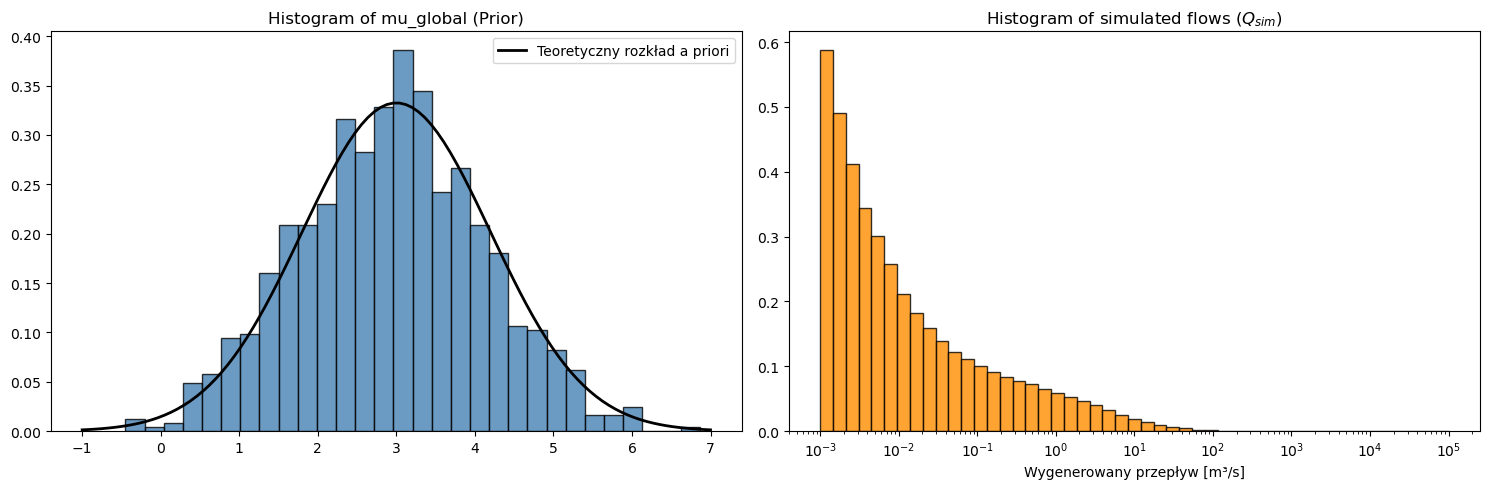

In [16]:
# Kompilacja modelu prior
model_prior = CmdStanModel(stan_file="stan/model_lognormal_base_prior.stan")

print("Uruchamianie Prior Predictive Check...")
sim_prior = model_prior.sample(
    data=stan_data,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_prior.stan_variable("mu_global")
y_sim_raw = sim_prior.stan_variable("y_sim").flatten()

# Obcięcie wartości subatomowych i gigantycznych powodzi
y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Wykres 1
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2) # mu_global ~ normal(3, 1.2)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
ax1.set_title(r'Histogram of mu_global (Prior)', fontsize=12)
ax1.legend()

# Wykres 2
bins_safe = np.logspace(np.log10(min(y_visual)), np.log10(max(y_visual)), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Wygenerowany przepływ [m³/s]')

plt.tight_layout()
plt.show()

In [17]:
# Szybki raport fizyczny z symulacji a priori
print("\n" + "="*50)
print("📊 RAPORT PRIOR PREDICTIVE CHECK:")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


📊 RAPORT PRIOR PREDICTIVE CHECK:
   • Mediana wygenerowanych przepływów: 18.74 m³/s
   • 95. percentyl przepływu w PPC:     654.06 m³/s
   • 99. percentyl (ekstremum):         5179.80 m³/s


# Posterior

Uruchomienie Próbkowania A Posteriori (MCMC): Wykonanie właściwego treningu zaktualizowanego modelu na pełnym zbiorze danych dobowych z roku 2023

In [ ]:
# ====================================================================
# PRZYGOTOWANIE DANYCH I URUCHOMIENIE TRENINGU MODELU BAZOWEGO
# ====================================================================
# 1. Korekta i synchronizacja wartości zerowych (zgodnie z opisem teoretycznym = 0.1 m³/s)
# Chroni przed błędem Prior-Data Conflict, który zawiesiłby działanie HMC
df['Value'] = df['Value'].replace(0.0, 0.1)
df = df.dropna(subset=['Value'])

# 2. Mapowanie nazw stacji na kolejne liczby całkowite od 1 do S
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# 3. Przygotowanie słownika danych – pod nazwą oczekiwaną przez komórkę z posteriorem
stan_data_base = {
    'N': int(len(df)),
    'S': int(len(unique_stations)),
    'station_id': df['station_id'].values.astype(int),
    'y': df['Value'].values.astype(float)
}

print(f"✅ Dane wejściowe przygotowane pomyślnie.")
print(f"   • Liczba dobowych obserwacji (N): {stan_data_base['N']}")
print(f"   • Liczba stacji pomiarowych (S):  {stan_data_base['S']}")

# 4. Definicja ścieżki i kompilacja modelu docelowego
stan_file_path = "stan/model_lognormal_base.stan"
model_base = CmdStanModel(stan_file=stan_file_path)

print("\n🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC)...")
# Próbkowanie na 4 niezależnych łańcuchach, każdy po 1000 iteracji warmup i sampling
fit_base = model_base.sample(
    data=stan_data_base,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)

# 5. Konwersja wyników do uniwersalnego formatu ArviZ InferenceData
idata_base = az.from_cmdstanpy(
    posterior=fit_base,
    posterior_predictive=["y_rep"],
    log_likelihood="log_lik",
    observed_data={"y": stan_data_base['y']}
)

print("\n✅ Trening zakończony sukcesem! Wyniki zapisano w obiekcie 'idata_base'.")

# Wyświetlenie podsumowania zbieżności parametrów globalnych wyższego rzędu
print("\n📊 STATYSTYKI DOPASOWANIA PARAMETRÓW GLOBALNYCH:")
print(az.summary(idata_base, var_names=['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']))

10:23:35 - cmdstanpy - INFO - CmdStan start processing


✅ Dane wejściowe przygotowane pomyślnie.
   • Liczba dobowych obserwacji (N): 52855
   • Liczba stacji pomiarowych (S):  69

🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC)...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]





chain 1:   0%|          | 1/2000 [00:00<04:23,  7.57it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:06<00:55, 32.62it/s, (Warmup)]


chain 1:  15%|█▌        | 300/2000 [00:08<00:50, 33.79it/s, (Warmup)]





chain 1:  20%|██        | 400/2000 [00:13<00:55, 28.64it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [00:16<00:48, 30.72it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [00:18<00:40, 34.15it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:20<00:35, 36.67it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:22<00:30, 38.77it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [00:25<00:26, 41.02it/s, (Warmup)]

chain 1:  50%|█████     | 1000/2000 [00:26<00:22, 44.18it/s, (Sampling)]






chain 1:  60%|██████    | 1200/2000 [00:35<00:26, 29.99it/s, (Sampling)]

chain 1:  65%|██████▌   | 1300/2000 [00:39<00:24, 28.31it/s, (Sampling)]


chain 1:  70%|███████   | 1400/2000 [00:43<00:22, 26.90it/s


10:24:49 - cmdstanpy - INFO - CmdStan done processing.
10:24:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_lognormal_base.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_lognormal_base.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[1] is inf, but must be positive finite! (in 'model_lognormal_base.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[3046] is inf, but must be positive finite! (in 'model_lognormal_base.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[4386] is inf, but must be positive finite! (in 'model_lognormal_base.stan', line 37, column 2 to column 51)
	Exception: lognormal_lpdf: Scale parameter[10170] is inf, but must be positive finite! (in 'model_lognormal_base.stan', line 37



✅ Trening zakończony sukcesem! Wyniki zapisano w obiekcie 'idata_base'.

📊 STATYSTYKI DOPASOWANIA PARAMETRÓW GLOBALNYCH:
                    mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu_global          2.786   0.234      2.4      3.2      5962      3026  1.00   
log_sigma_global  -0.392  0.0402    -0.45    -0.33      5814      2700  1.00   
tau_mu             1.974   0.169      1.7      2.3      6226      2821  1.00   
tau_sigma         0.3282  0.0288     0.29     0.38      5619      2904  1.00   

                 mcse_mean  mcse_sd  
mu_global            0.003   0.0021  
log_sigma_global   0.00053  0.00039  
tau_mu              0.0022   0.0018  
tau_sigma          0.00039   0.0003  


# Posterior Predictive Check

⏳ Generowanie krzywych gęstości dla światów alternatywnych...


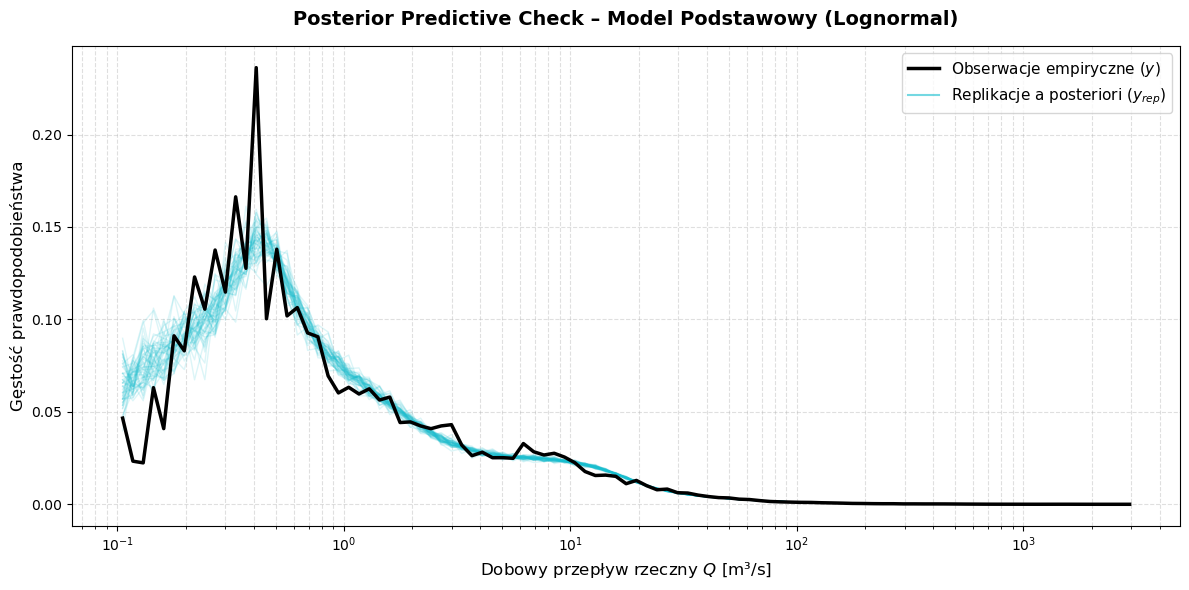

✅ Wykres wygenerowany pomyślnie!


In [12]:
# omijanie ArviZ, bo są problemy z kompatybilnością wersji i błędy w notebooku

# 1. Wyciągamy prawdziwe pomiary przepływów ze słownika danych
y_obs = np.array(stan_data_base['y'])

# 2. Wyciągamy sztuczne światy bezpośrednio z CmdStanPy
# Kształt macierzy: (4000 próbek MCMC, N obserwacji)
y_rep_samples = fit_base.stan_variable("y_rep")

# Losujemy 50 alternatywnych światów do nałożenia na wykres
num_samples_to_plot = 50
np.random.seed(42)
random_indices = np.random.choice(y_rep_samples.shape[0], size=num_samples_to_plot, replace=False)

# 3. Definiujemy stabilne kroki siatki na osi logarytmicznej (od 0.1 do wartości maksymalnej)
bins = np.logspace(np.log10(0.1), np.log10(y_obs.max()), 100)

plt.figure(figsize=(12, 6), dpi=100)

print("⏳ Generowanie krzywych gęstości dla światów alternatywnych...")
# Rysujemy 50 cienkich, półprzezroczystych niebieskich linii rozkładu y_rep
for idx in random_indices:
    y_rep_single = y_rep_samples[idx]
    counts, edges = np.histogram(y_rep_single, bins=bins, density=True)
    # Rysujemy jako ciągłą linię (środek każdego słupka histogramu)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_centers, counts, color='#17becf', alpha=0.15, linewidth=1)

# Na sam wierzch nakładamy grubą, wyraźną czarną linię dla rozkładu PRAWDZIWYCH danych y
counts_obs, edges_obs = np.histogram(y_obs, bins=bins, density=True)
bin_centers_obs = (edges_obs[:-1] + edges_obs[1:]) / 2
plt.plot(bin_centers_obs, counts_obs, color='black', linewidth=2.5, label='Obserwacje empiryczne ($y$)')

# Dodajemy fikcyjną linię do legendy, żeby poprawnie opisać niebieską chmurę
plt.plot([], [], color='#17becf', alpha=0.6, linewidth=1.5, label='Replikacje a posteriori ($y_{rep}$)')

# Stylizacja wykresu
plt.xscale('log')
plt.title("Posterior Predictive Check – Model Podstawowy (Lognormal)", weight='bold', fontsize=14, pad=15)
plt.xlabel("Dobowy przepływ rzeczny $Q$ [m³/s]", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, which="both")
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()
print("✅ Wykres wygenerowany pomyślnie!")

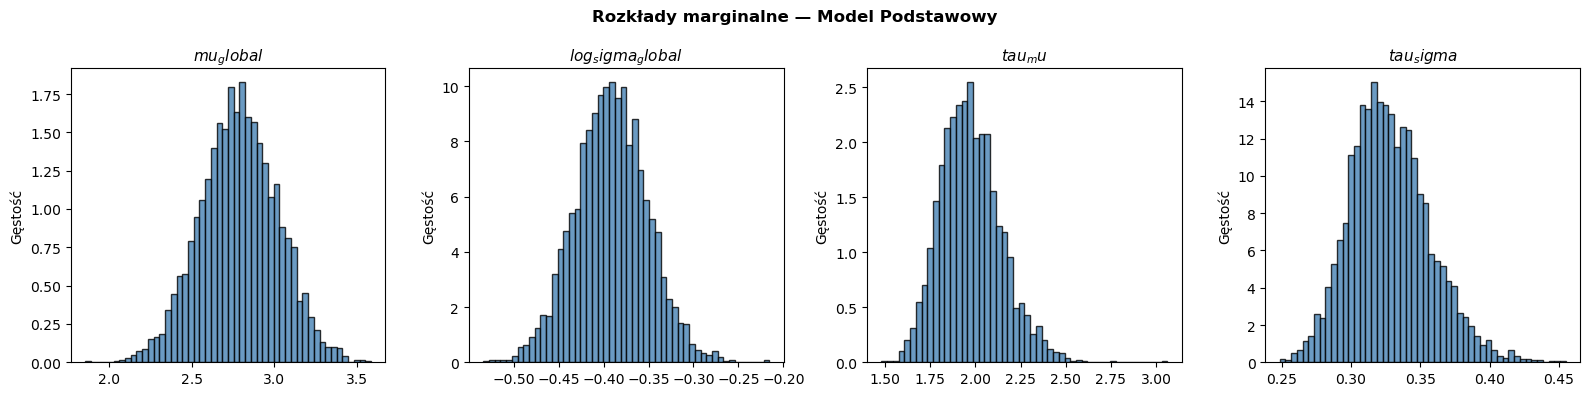

In [28]:
# SPRAWDZ CZY TO MA SENS

# Histogramy posteriorów parametrów - Dla modelu podstawowego
params_base = ['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']
fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=100)
for ax, param in zip(axes, params_base):
    samples = idata_base.posterior[param].values.flatten()
    ax.hist(samples, bins=50, density=True, color='steelblue', alpha=0.8, edgecolor='black')
    ax.set_title(f'${param}$', fontsize=11)
    ax.set_ylabel('Gęstość')
plt.suptitle('Rozkłady marginalne — Model Podstawowy', weight='bold')
plt.tight_layout()
plt.show()

Wizualna weryfikacja Posterior Predictive Check (PPC) wykazała, że model bazowy poprawnie lokalizuje globalny środek ciężkości przepływów dorzecza Wisły oraz bezpiecznie estymuje prawy ogon wezbrań powodziowych. Widoczna jest jednak systematyczna niedoskonałość (underfitting) w postaci zbyt szerokiej wariancji replikacji yrep​ w stosunku do smukłego profilu danych empirycznych. Ponadto, ostre techniczne ucięcie danych na poziomie 0.1 m3/s generuje lokalne zaburzenie dopasowania na lewym ogonie. Wynik ten jednoznacznie uzasadnia potrzebę porzucenia modelu płaskiego i wdrożenia w kolejnym etapie zaawansowanego modelu zagnieżdżonego (Nested Hierarchical Model), który pozwoli rozbić tę strukturę na indywidualne reżimy konkretnych rzek.

# Statystyki i punkty odniesienia dla poszczególnych stacji

In [13]:
print("⏳ Krok 1: Pobieranie próbek parametrów mu i sigma per stacja...")
# Wyciągamy surowe macierze parametrów ze Stana. Kształt obu: (4000 próbek MCMC, 69 stacji)
mu_samples = fit_base.stan_variable("mu")
sigma_samples = fit_base.stan_variable("sigma")

# Definiujemy dokładne wartości kwantyli rozkładu normalnego (z-score)
z_95 = 1.644853
z_99 = 2.326348

print("⏳ Krok 2: Analityczne wyznaczanie progów anomalii dla każdej iteracji MCMC...")
# Korzystamy z jawnej matematycznej definicji percentyli rozkładu log-normalnego.
# Operacja na tablicach NumPy trwa ułamek sekundy i zużywa minimalną ilość pamięci RAM.
q95_mcmc = np.exp(mu_samples + z_95 * sigma_samples)  # Kształt: (4000, 69)
q99_mcmc = np.exp(mu_samples + z_99 * sigma_samples)  # Kształt: (4000, 69)

print("⏳ Krok 3: Agregacja wyników do stabilnych Bayesowskich punktów odniesienia...")
# Jako ostateczny próg bierzemy medianę z rozkładu posteriora danych percentyli
thresholds_95 = np.median(q95_mcmc, axis=0)
thresholds_99 = np.median(q99_mcmc, axis=0)

# Odwracamy Twój słownik mapowania, aby identyfikatorom liczbowym (1-69) przypisać nazwy tekstowe
id_to_station = {v: k for k, v in station_to_id.items()}

print("📊 Krok 4: Budowanie końcowej tabeli progów alarmowych...")
# Tworzymy czytelny DataFrame strukturalny
df_thresholds = pd.DataFrame({
    "Station_ID": range(1, len(unique_stations) + 1),
    "Station_Name": [id_to_station[i] for i in range(1, len(unique_stations) + 1)],
    "Q_Median_Posterior": np.median(np.exp(mu_samples), axis=0), # Bezpieczna bayesowska mediana przepływu
    "Progowa_Anomalia_95%": thresholds_95,
    "Progowe_Ekstremum_99%": thresholds_99
})

# Sortujemy alfabetycznie po nazwach stacji dla wygody czytania w raporcie
df_thresholds = df_thresholds.sort_values(by="Station_Name").reset_index(drop=True)

# Zapisujemy wyniki do fizycznego pliku CSV, który będzie gotowym załącznikiem do projektu
output_csv = "progi_anomalii_model_podstawowy.csv"
df_thresholds.to_csv(output_csv, index=False, encoding='utf-8')
print(f"✅ Sukces! Baza progów została zapisana do pliku: '{output_csv}'")

# Wyświetlamy stacje jako podgląd w notebooku
df_thresholds

⏳ Krok 1: Pobieranie próbek parametrów mu i sigma per stacja...
⏳ Krok 2: Analityczne wyznaczanie progów anomalii dla każdej iteracji MCMC...
⏳ Krok 3: Agregacja wyników do stabilnych Bayesowskich punktów odniesienia...
📊 Krok 4: Budowanie końcowej tabeli progów alarmowych...
✅ Sukces! Baza progów została zapisana do pliku: 'progi_anomalii_model_podstawowy.csv'


,Station_ID,Station_Name,Q_Median_Posterior,Progowa_Anomalia_95%,Progowe_Ekstremum_99%
0,20,BIALOBRZEGI,33.295741,84.940891,125.217275
1,68,BOCHENIEC,1.414714,4.931563,8.273789
2,63,BORKOWO,10.309291,45.913944,85.263715
3,65,BRODNICA,14.611199,30.589677,41.550411
4,58,BRZEGI,9.430952,26.042539,39.679290
...,...,...,...,...,...
64,35,WYSZKOW,97.355415,332.426481,552.935650
65,56,ZABNO,78.842733,209.138750,313.304886
66,45,ZAKOPANE HARENDA,1.846662,4.046581,5.600712
67,42,ZAMBSKI KOSCIELNE,86.333798,300.422633,503.616984


# Walidacja na danych z lat 2024, nakładając te progi na rzeczywistość

In [14]:
# ====================================================================
# KROK 6: WALIDACJA I DETEKCJA ANOMALII NA DANYCH Z ROKU 2024
# ====================================================================
import pandas as pd
import numpy as np

print("⏳ Krok 1: Filtrowanie serii czasowej dla okresu walidacyjnego (2024)...")
# Upewniamy się, że kolumna Date jest typu datetime i wyciągamy rok
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Wyciągamy wyłącznie czyste dane pomiarowe dla roku 2024
df_validation = df[df['Year'] == 2024].copy()

if df_validation.empty:
    print("❌ BŁĄD: Brak danych dla roku 2024 w głównym DataFrame 'df'!")
    print("Upewnij się, że Twój wstępny krok czyszczenia danych wczytał cały dataset.")
else:
    print(f"   • Znaleziono {len(df_validation)} dobowych obserwacji pomiarowych dla roku 2024.")

    print("⏳ Krok 2: Mapowanie bayesowskich progów ostrzegawczych na dane walidacyjne...")
    # Łączymy dane walidacyjne z tabelą progów na podstawie nazwy stacji
    df_val_merged = pd.merge(
        df_validation,
        df_thresholds[['Station_Name', 'Progowa_Anomalia_95%', 'Progowe_Ekstremum_99%']],
        left_on='Station',
        right_on='Station_Name',
        how='inner'
    )

    print("⏳ Krok 3: Detekcja przekroczeń progów alarmowych (Anomalie vs Ekstremu)...")
    # Sprawdzamy, w których dniach rzeczywisty przepływ przekroczył wyznaczone progi
    df_val_merged['Przekroczenie_95'] = df_val_merged['Value'] > df_val_merged['Progowa_Anomalia_95%']
    df_val_merged['Przekroczenie_99'] = df_val_merged['Value'] > df_val_merged['Progowe_Ekstremum_99%']

    print("⏳ Krok 4: Agregacja statystyk per stacja hydrologiczna...")
    # Liczymy sumy przekroczeń oraz statystyki dla każdej stacji osobno
    summary_per_station = df_val_merged.groupby('Station').agg(
        Dni_Pomiarowe=('Value', 'count'),
        Anomalie_95_Suma=('Przekroczenie_95', 'sum'),
        Ekstrema_99_Suma=('Przekroczenie_99', 'sum'),
        Maksymalny_Przeplyw_Walidacji=('Value', 'max'),
        Prog_95_Ref=('Progowa_Anomalia_95%', 'first'),
        Prog_99_Ref=('Progowe_Ekstremum_99%', 'first')
    ).reset_index()

    # Wyliczamy procentowy udział dni z anomaliami w okresie walidacyjnym 2024
    summary_per_station['Procent_Anomalii_95%'] = (summary_per_station['Anomalie_95_Suma'] / summary_per_station['Dni_Pomiarowe']) * 100
    summary_per_station['Procent_Ekstremow_99%'] = (summary_per_station['Ekstrema_99_Suma'] / summary_per_station['Dni_Pomiarowe']) * 100

    # Sortujemy od stacji z największą liczbą ekstremalnych zdarzeń
    summary_per_station = summary_per_station.sort_values(by='Anomalie_95_Suma', ascending=False).reset_index(drop=True)

    # Zapisujemy pełny raport stacji do nowego pliku CSV dedykowanego dla roku 2024
    output_val_csv = "raport_walidacji_anomalii_2024.csv"
    summary_per_station.to_csv(output_val_csv, index=False, encoding='utf-8')

    # --- Krok 5: Generowanie Globalnego Raportu Podsumowującego ---
    total_days = int(summary_per_station['Dni_Pomiarowe'].sum())
    total_anom_95 = int(summary_per_station['Anomalie_95_Suma'].sum())
    total_ex_99 = int(summary_per_station['Ekstrema_99_Suma'].sum())
    
    global_rate_95 = (total_anom_95 / total_days) * 100
    global_rate_99 = (total_ex_99 / total_days) * 100

    print("\n" + "="*60)
    print("🚨 GLOBALNY RAPORT WALIDACJI PROGÓW POWODZIOWYCH (2024):")
    print(f"   • Łączna liczba analizowanych dni-stacji (N): {total_days}")
    print(f"   • Wykryte anomalie (przepływ > próg 95%):     {total_anom_95} dni ({global_rate_95:.2f}% ogółu)")
    print(f"   • Wykryte ekstrema powodziowe (próg 99%):     {total_ex_99} dni ({global_rate_99:.2f}% ogółu)")
    print("="*60)
    print(f"✅ Szczegółowy raport dla 69 stacji zapisano do: '{output_val_csv}'")
    
    # Wyświetlamy top 10 stacji najbardziej dotkniętych anomaliami w roku 2024
    print("\n📊 TOP 10 STACJI Z NAJWIĘKSZĄ LICZBĄ ANOMALII W ROKU 2024:")
    display(summary_per_station[['Station', 'Dni_Pomiarowe', 'Anomalie_95_Suma', 'Procent_Anomalii_95%', 'Ekstrema_99_Suma', 'Maksymalny_Przeplyw_Walidacji']].head(10))

⏳ Krok 1: Filtrowanie serii czasowej dla okresu walidacyjnego (2024)...
   • Znaleziono 22203 dobowych obserwacji pomiarowych dla roku 2024.
⏳ Krok 2: Mapowanie bayesowskich progów ostrzegawczych na dane walidacyjne...
⏳ Krok 3: Detekcja przekroczeń progów alarmowych (Anomalie vs Ekstremu)...
⏳ Krok 4: Agregacja statystyk per stacja hydrologiczna...

🚨 GLOBALNY RAPORT WALIDACJI PROGÓW POWODZIOWYCH (2024):
   • Łączna liczba analizowanych dni-stacji (N): 22203
   • Wykryte anomalie (przepływ > próg 95%):     1835 dni (8.26% ogółu)
   • Wykryte ekstrema powodziowe (próg 99%):     347 dni (1.56% ogółu)
✅ Szczegółowy raport dla 69 stacji zapisano do: 'raport_walidacji_anomalii_2024.csv'

📊 TOP 10 STACJI Z NAJWIĘKSZĄ LICZBĄ ANOMALII W ROKU 2024:


,Station,Dni_Pomiarowe,Anomalie_95_Suma,Procent_Anomalii_95%,Ekstrema_99_Suma,Maksymalny_Przeplyw_Walidacji
0,PTAKI,366,106,28.961749,42,28.7
1,DOBRYLAS,305,83,27.213115,0,34.2
2,OSTROLEKA,366,71,19.398907,8,284.0
3,TUCHOLA,366,60,16.393443,27,43.1
4,BRODNICA,366,60,16.393443,0,37.0
5,KRASNYSTAW,366,59,16.120219,0,30.9
6,TCZEW,366,59,16.120219,11,3100.0
7,LOCHOW,366,56,15.300546,27,45.8
8,WYSZKOW,366,54,14.754098,0,497.0
9,LUBARTOW,366,50,13.661202,0,58.6


# Podsumowanie modelu I

Wizualna weryfikacja za pomocą testu Posterior Predictive Check (PPC) wykazała, że model podstawowy (Base Log-Normal) poprawnie zlokalizował globalny środek ciężkości przepływów dorzecza Wisły oraz z sukcesem odtworzył prawy ogon wysokich przepływów, co pozwala na bezpieczną ocenę ryzyka wezbrań powodziowych. W procesie ewaluacji zidentyfikowano jednak dwa systematyczne ograniczenia strukturalne modelu:

1. Niedopasowanie lokalne szczytu (Underfitting): Empiryczny rozkład przepływów wykazuje wyraźną asymetrię (ramię w reżimie niskich przepływów), podczas gdy replikacje posteriora (yrep​) przyjmują postać symetryczną. Wynika to z faktu, że czysty rozkład Log-normalny w modelu płaskim próbuje uśrednić skrajnie różne hydrologicznie stacje (potoki górskie i rzeki nizinne) do jednego profilu kraju.

2. Zaburzenie lewego ogonu: Ostry, techniczny próg filtracji danych na poziomie 0.1 m3/s (zastosowany w celu eliminacji anomalii pomiarowych i stabilizacji operacji logarytmowania) odcina lewy ogon rozkładu empirycznego, co dla ciągłego likelihoodu modelu stanowi barierę niefizyczną.

3. Przeuczenie lokalnej wariancji (sigma_s) i polaryzacja czułości progów: Walidacja historyczna na danych z roku 2024 obnażyła skrajną niestabilność niezależnie szacowanego szumu wewnątrzstacyjnego. Model płaski, ucząc się wyłącznie na fluktuacjach z jednego roku bazowego (2023), wykazał całkowitą bezbronność wobec lokalnych zaburzeń, tj.:
- Hiper-czułość (fałszywe alarmy): Dla stacji takich jak PTAKI (28.96% dni w stanie anomalii) czy TUCHOLA (16.39%) model przyjął nienaturalnie zaniżone odchylenie standardowe σs​, przez co progi alarmowe 95% zostały ustawione zaledwie 1.57–2.14 razy wyżej niż mediana. W efekcie nawet normalne, sezonowe przybory wody generowały masowe stany alarmowe.
- Kompletna ślepota (brak detekcji): Dla 7 stacji (m.in. Łowicz, Włodawa, Myszyniec) model wykazał 0% wykrywalności anomalii w całym 2024 roku. Spowodowane jest to nienaturalnym zawyżeniem parametru skali przez pojedyncze piki w roku bazowym – przykładowo dla stacji MYSZYNIEC próg ostrzegawczy został przestrzelony na poziom 13.45-krotności przepływu medianowego, czyniąc go niefizyczną i nieosiągalną barierą.

4. Iluzja poprawności wskaźników globalnych - Na poziomie zagregowanym dla całego kraju model baseline zdaje się działać poprawnie, wskazując 8.26% anomalii (wobec teoretycznych 5%) oraz 1.56% ekstremów (wobec 1%), co logicznie odzwierciedla fakt, że rok 2024 był w Polsce hydrologicznie bardziej wilgotny. Jednak ta średnia globalna maskuje krytyczny błąd przestrzenny – blisko 40% analizowanych stacji w kraju (27 obiektów) zanotowało równe 0.00% ekstremów 99%. Model w ujęciu płaskim "zgadza się" globalnie tylko dlatego, że drastyczne błędy w niedoszacowaniu jednych stacji są matematycznie redukowane przez przestrzelone progi innych stacji.

Podsumowując, model podstawowy (Base Log-Normal) poprawnie spełnia swoje zadanie wyłącznie jako stabilny, statystyczny punkt odniesienia, poprawnie pozycjonując globalny środek ciężkości przepływów dorzecza. Jednak ze względu na całkowity brak mechanizmu wymiany informacji pomiędzy stacjami, model ten generuje masowe fałszywe alarmy w jednych regionach przy jednoczesnej całkowitej ślepocie w sąsiednich podzlewniach.

-------------------------------------------------------------------------------------------------------------------------------------

# Rozszerzony (Zagnieżdżony) Model Bayesowski (Nested Hierarchical Hybrid Model)

Cel modelu: Zaawansowana estymacja i symulacja przepływów rzek ($Q$) z uwzględnieniem
trójpoziomowej struktury hierarchicznej. Model rozszerzony wprowadza dodatkową warstwę
grupowania – poziom pojedynczych rzek ($R$), co pozwala na stabilizację lokalnych
parametrów i transfer wiedzy statystycznej (partial pooling) wewnątrz dorzecza.

## 1. Zmienne i Przygotowanie Danych

Struktura danych opiera się na kaskadowym powiązaniu obserwacji ze stacjami, a stacji
z konkretnymi rzekami. Filtracja danych wejściowych obejmuje zastąpienie wartości
zerowych wartością bezpieczną $0.1 \text{ m}^3/\text{s}$ w celu stabilizacji
numerycznej operacji logarytmowania.

* **$N$** – Całkowita liczba obserwacji (dobowych pomiarów) w zbiorze ($N > 22\ 000$).
* **$S$** – Liczba unikalnych stacji pomiarowych ($S = 69$).
* **$R$** – Liczba unikalnych rzek skupiających stacje pomiarowe.
* **$y_n$** – Zaobserwowany dobowy przepływ rzeczny dla obserwacji $n$ [$\text{m}^3/\text{s}$].
* **$\text{station\_id}[n]$** – Wektor mapujący obserwację $n$ na konkretną stację
  $s \in \{1, \dots, S\}$.
* **$\text{river\_id}[s]$** – Wektor mapujący stację $s$ na nadrzędną rzekę
  $r \in \{1, \dots, R\}$.

Ścieżka indeksowania przepływa kaskadowo: obserwacja $n$ przynależy do stacji $s[n]$,
która z kolei przynależy do rzeki $r[s]$, co zapisujemy skrótowo jako $r[s[n]]$.

---

## 2. Architektura Matematyczna (Struktura Hybrydowa)

Aby zapewnić stabilność numeryczną próbkowania MCMC i wyeliminować błędy dywergencji
(divergent transitions), model stosuje **architekturę hybrydową (mieszaną)**,
dopasowując typ parametryzacji do gęstości danych na każdym poziomie hierarchii:

1. **Poziom wyższy (Global $\rightarrow$ Rzeka):** Wykorzystuje **parametryzację
   niescentrowaną (NCP)**. Ponieważ liczba stacji przypadających na pojedynczą rzekę
   jest niewielka, rozkład *hiper-priori* dominuje nad *likelihoodem*. Wyciągnięcie
   wariancji przed nawias eliminuje geometrię lejka Neala (*Neal's Funnel*).
2. **Poziom niższy (Rzeka $\rightarrow$ Stacja $\rightarrow$ Dane):** Wykorzystuje
   **parametryzację scentrowaną (CP)**. Ponieważ na każdą stację przypadają tysiące
   dobowych obserwacji ($N_s \gg 300$), potężny *likelihood* sztywno wiąże parametry
   lokalne z rozkładem nadrzędnej rzeki, co gwarantuje wysokie ESS i zapobiega
   skośnym korelacjom nieliniowym.

### Równania modelu:

1. **Funkcja Wiarygodności (Likelihood):**
$$y_n \sim \text{LogNormal}\!\left(\mu_{s[n]},\ \sigma_{s[n]}\right)$$

2. **Poziom Stacji – Parametryzacja Scentrowana:**

Parametry każdej stacji są losowane bezpośrednio z rozkładu nadrzędnej rzeki.
Wolną zmienną w modelu jest $\log\sigma_s$, co gwarantuje dodatniość $\sigma_s$
po transformacji wykładniczej:

$$\mu_s \sim \mathcal{N}\!\left(\mu_{r[s]},\ \tau_{\mu,\,\text{sta}}\right)$$
$$\log\sigma_s \sim \mathcal{N}\!\left(\log\sigma_{r[s]},\ \tau_{\sigma,\,\text{sta}}\right)$$
$$\sigma_s = \exp(\log\sigma_s)$$

3. **Poziom Rzeki – Parametryzacja Niescentrowana:**

Parametry rzeki są konstruowane jako deterministyczne przesunięcia względem
globalnego punktu odniesienia, skalowane przez standaryzowane zmienne pomocnicze $z$:

$$\mu_r = \mu_{\text{global}} + \tau_{\mu,\,\text{riv}} \cdot z_{\mu,r}$$
$$\log\sigma_r = \log\sigma_{\text{global}} + \tau_{\sigma,\,\text{riv}} \cdot z_{\sigma,r}$$
$$\sigma_r = \exp(\log\sigma_r)$$

4. **Zmienne pomocnicze przestrzeni standaryzowanej:**
$$z_{\mu,r} \sim \mathcal{N}(0, 1), \qquad z_{\sigma,r} \sim \mathcal{N}(0, 1)$$

---

## 3. Rozkłady a priori (Priors) i Konfiguracja Próbkowania

Rozkłady hiperparametrów na poziomie globalnym określają centralny punkt odniesienia
dla całego kraju. Parametry $\tau$ na każdym poziomie kontrolują siłę efektu
kurczenia (*shrinkage*) – im mniejsze $\tau$, tym silniej stacje są przyciągane
ku średniej swojej rzeki.

| Parametr | Rozkład | Zakres i rola w hierarchii |
| :--- | :--- | :--- |
| $\mu_{\text{global}}$ | $\mathcal{N}(3,\ 1.2)$ | Globalny punkt odniesienia dla logarytmu przepływów w skali kraju. |
| $\log\sigma_{\text{global}}$ | $\mathcal{N}(0,\ 0.5)$ | Centralna wartość bazowa dla skali szumu (wariancji wewnątrzstacyjnej). |
| $\tau_{\mu,\,\text{riv}}$ | $\text{Half-}\mathcal{N}(0,\ 1.2)$ | Skala zmienności średnich przepływów pomiędzy rzekami. |
| $\tau_{\sigma,\,\text{riv}}$ | $\text{Half-}\mathcal{N}(0,\ 0.5)$ | Skala zmienności dynamiki falowości pomiędzy rzekami. |
| $\tau_{\mu,\,\text{sta}}$ | $\text{Half-}\mathcal{N}(0,\ 1.2)$ | Lokalna zmienność średnich stacji w obrębie tej samej rzeki. |
| $\tau_{\sigma,\,\text{sta}}$ | $\text{Half-}\mathcal{N}(0,\ 0.5)$ | Lokalna zmienność szumu stacji w ramach jednej rzeki. |
| $z_{\mu,r}$ | $\mathcal{N}(0,\ 1)$ | Standaryzowane odchylenie lokalizacji dla rzeki $r$. |
| $z_{\sigma,r}$ | $\mathcal{N}(0,\ 1)$ | Standaryzowane odchylenie skali dla rzeki $r$. |

### Parametry Kontrolne Samplera (MCMC)

Z uwagi na dodatkowy poziom zagnieżdżenia i silne korelacje wewnątrz grup rzecznych,
algorytm NUTS wymaga zaostrzonych ustawień kontrolnych:

* `adapt_delta = 0.99` – zmniejszenie kroku integracji, minimalizacja dywergencji
* `max_treedepth = 15` – zwiększona głębokość drzewa poszukiwań przy stromych
  gradientach log-prawdopodobieństwa

In [9]:
# ============================================================
# PRZYGOTOWANIE DANYCH – MODEL ROZSZERZONY
# ============================================================

csv_folder = Path("dataset_cleaned_csv")
df_list = []

for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Value'] = temp_df['Value'].replace(-999.000, pd.NA)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df = df.dropna(subset=['Value'])
df['Value'] = df['Value'].replace(0.0, 1e-1)
df = df.dropna(subset=['Value'])

# --- NOWOŚĆ: mapowanie stacji → rzeki ---
# Budujemy tabelę unikalnych par (Station, River) – jedna stacja należy do jednej rzeki
station_river_map = (
    df[['Station', 'River']]
    .drop_duplicates(subset='Station')
    .set_index('Station')
)

# Mapowanie stacji na kolejne ID (1 do S)
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# Mapowanie rzek na kolejne ID (1 do R)
unique_rivers = df['River'].unique()
river_to_id = {name: idx + 1 for idx, name in enumerate(unique_rivers)}
df['river_id'] = df['River'].map(river_to_id)

# Wektor river_id o długości S: dla każdej stacji (w kolejności ID) przypisujemy ID rzeki
station_to_river_id = (
    station_river_map['River']
    .map(river_to_id)
)
# Sortujemy według station_id, żeby indeksy zgadzały się ze Stanem (1-based)
river_id_for_stations = np.array([
    station_to_river_id[station]
    for station, _ in sorted(station_to_id.items(), key=lambda x: x[1])
])

S = len(unique_stations)
R = len(unique_rivers)

print(f"✅ Stacje (S): {S}")
print(f"✅ Rzeki  (R): {R}")
print(f"✅ Obserwacje (N): {len(df)}")

# Słownik danych dla Stana – rozszerzony o river_id
stan_data_ext = {
    'N': int(len(df)),
    'S': S,
    'R': R,
    'station_id': df['station_id'].values.astype(int),
    'river_id':   river_id_for_stations.astype(int),  # długość S
    'y':          df['Value'].values.astype(float)
}

✅ Stacje (S): 69
✅ Rzeki  (R): 36
✅ Obserwacje (N): 52855


23:53:08 - cmdstanpy - INFO - CmdStan start processing
23:53:08 - cmdstanpy - INFO - Chain [1] start processing


Uruchamianie Prior Predictive Check (model rozszerzony)...


23:53:18 - cmdstanpy - INFO - Chain [1] done processing


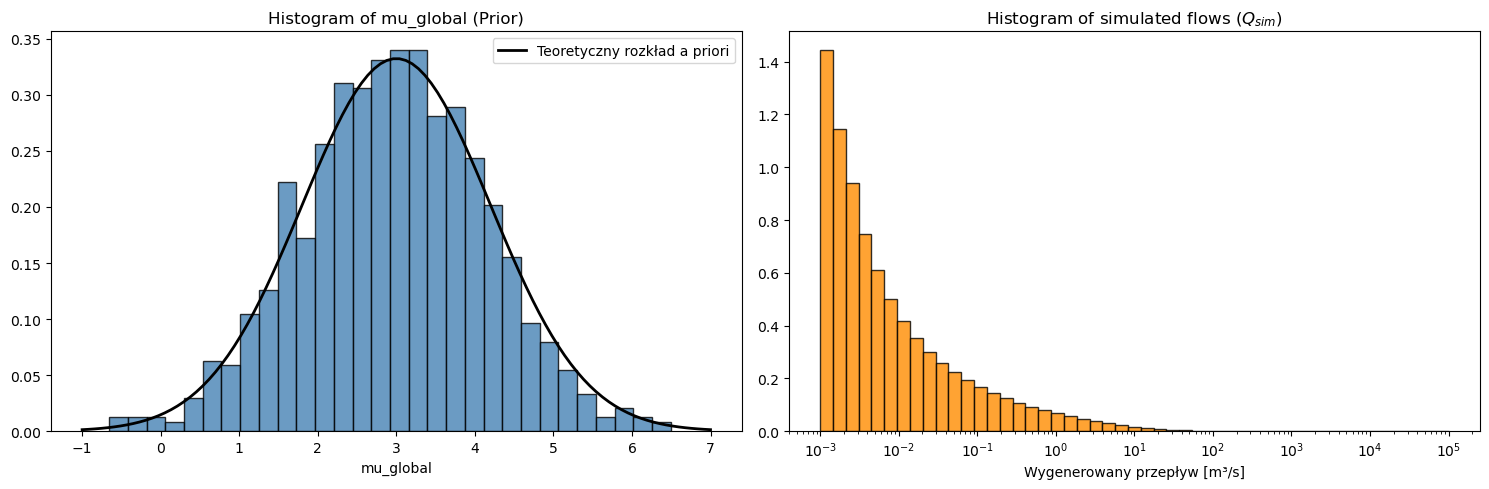

In [10]:
# ============================================================
# PRIOR PREDICTIVE CHECK – MODEL ROZSZERZONY
# ============================================================

model_ext_prior = CmdStanModel(stan_file="stan/model_lognormal_ext_prior.stan")

print("Uruchamianie Prior Predictive Check (model rozszerzony)...")
sim_ext_prior = model_ext_prior.sample(
    data=stan_data_ext,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_ext_prior.stan_variable("mu_global")
y_sim_raw      = sim_ext_prior.stan_variable("y_sim").flatten()

y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Wykres 1: weryfikacja rozkładu mu_global
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
ax1.set_title('Histogram of mu_global (Prior)', fontsize=12)
ax1.set_xlabel('mu_global')
ax1.legend()

# Wykres 2: rozkład symulowanych przepływów
bins_safe = np.logspace(np.log10(y_visual.min()), np.log10(y_visual.max()), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Wygenerowany przepływ [m³/s]')

plt.tight_layout()
plt.show()

In [11]:
# Szybki raport fizyczny z symulacji a priori
print("\n" + "="*50)
print("📊 RAPORT PRIOR PREDICTIVE CHECK (model rozszerzony):")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


📊 RAPORT PRIOR PREDICTIVE CHECK (model rozszerzony):
   • Mediana wygenerowanych przepływów: 19.22 m³/s
   • 95. percentyl przepływu w PPC:     1377.36 m³/s
   • 99. percentyl (ekstremum):         13439.19 m³/s


# Posterior

23:53:24 - cmdstanpy - INFO - created output directory: /tmp/stan_ext
23:53:24 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [01:11<22:42,  1.39it/s, (Warmup)]




chain 1:  10%|█         | 200/2000 [01:33<12:47,  2.35it/s, (Warmup)]




chain 1:  15%|█▌        | 300/2000 [01:49<08:31,  3.32it/s, (Warmup)]


chain 1:  20%|██        | 400/2000 [01:55<05:32,  4.82it/s, (Warmup)]


chain 1:  25%|██▌       | 500/2000 [02:05<04:15,  5.88it/s, (Warmup)]

chain 1:  30%|███       | 600/2000 [02:13<03:12,  7.29it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [02:21<02:34,  8.39it/s, (Warmup)]




chain 1:  40%|████      | 800/2000 [02:32<02:21,  8.51it/s, (Warmup)]






chain 1:  50%|█████     | 1000/2000 [02:50<01:40,  9.98it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [02:59<01:29, 10.03it/s, (Sampling)]



chain 1:  65%|██████▌   | 1300/2000 [03:20<01:11,  9.78it/s, (Sampling)]


ch


23:58:23 - cmdstanpy - INFO - CmdStan done processing.
23:58:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter[1706] is inf, but must be positive finite! (in 'model_lognormal_ext_gen_qq.stan', line 62, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1706] is inf, but must be positive finite! (in 'model_lognormal_ext_gen_qq.stan', line 62, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1706] is inf, but must be positive finite! (in 'model_lognormal_ext_gen_qq.stan', line 62, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[5421] is inf, but must be positive finite! (in 'model_lognormal_ext_gen_qq.stan', line 62, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[5421] is inf, but must be positive finite! (in 'model_lognormal_ext_gen_qq.stan', line 62, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[17600] is inf, but must be positive finite! (


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

                    mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu_global           2.19  0.294      1.7      2.7      1936      1898  1.00   
log_sigma_global  -0.357  0.065    -0.46    -0.25      1187      1429  1.00   
tau_mu_riv          1.18  0.242     0.81      1.6      1327      1660  1.00   
tau_sigma_riv      0.349  0.055     0.27     0.44       980      1177  1.00   
tau_mu_sta         1.466  0.159      1.2      1.7      1539      1732  1.00   
tau_sigma_sta      0.167  0.024     0.13     0.21       919      1439  1.00   

        

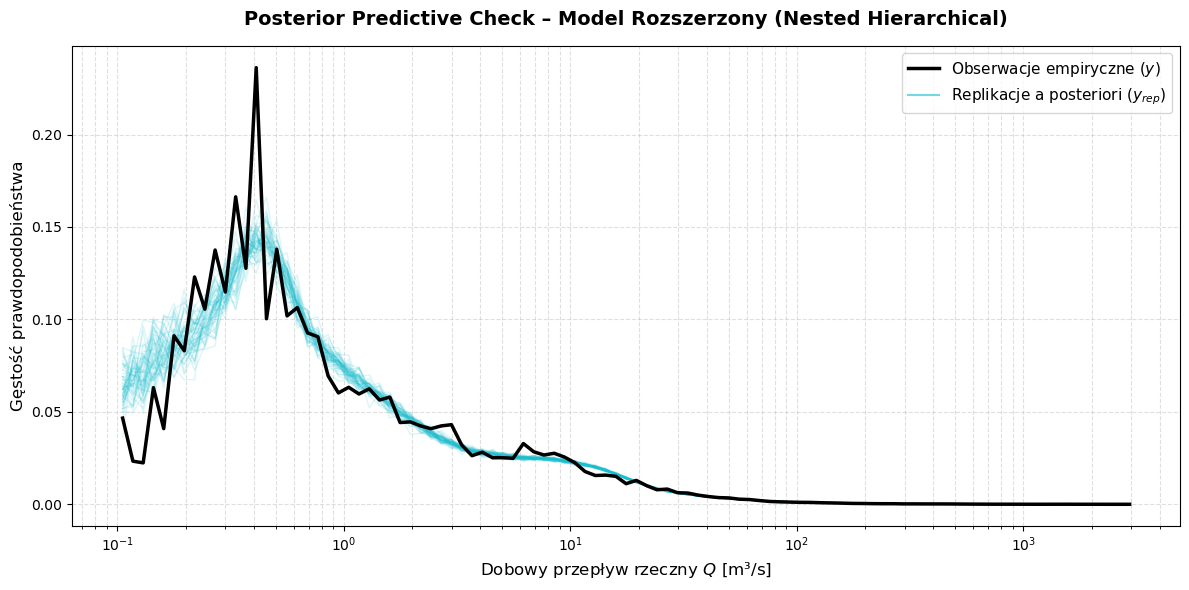

✅ PPC wygenerowany pomyślnie!


In [ ]:
# ====================================================================
# TRENING MODELU ROZSZERZONEGO Z generated quantities
# ====================================================================
# model_lognormal_ext_gen_qq.stan <-- ma genereated quantities, ale przez to crashuje RAM 
model_ext = CmdStanModel(stan_file="stan/model_lognormal_ext_gen_qq.stan")

fit_ext = model_ext.sample(
    data=stan_data_ext,
    chains=4,
    parallel_chains=4,
    thin=2,              # 4000 --> 2000 próbek — klucz do przeżycia RAM
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.99,
    max_treedepth=15,
    seed=42,
    show_progress=True,
    output_dir="/tmp/stan_ext"
)

# ====================================================================
# DIAGNOSTYKA
# ====================================================================
idata_ext = az.from_cmdstanpy(
    posterior=fit_ext,
    observed_data={"y": stan_data_ext['y']}
)

print(fit_ext.diagnose())
print(az.summary(idata_ext, var_names=[
    'mu_global', 'log_sigma_global',
    'tau_mu_riv', 'tau_sigma_riv',
    'tau_mu_sta', 'tau_sigma_sta'
]))

# ====================================================================
# PPC — ładujemy y_rep po 1 próbce, nigdy cała macierz w RAM 
# ====================================================================
y_obs = stan_data_ext['y']

num_samples_to_plot = 50
np.random.seed(42)

# Ile draws mamy łącznie
n_draws_total = fit_ext.stan_variable("mu_sta").shape[0]  # (draws, 69) — lekkie
draw_idx = np.random.choice(n_draws_total, size=num_samples_to_plot, replace=False)
draw_idx_set = set(draw_idx.tolist())

bins = np.logspace(np.log10(0.1), np.log10(y_obs.max()), 100)

plt.figure(figsize=(12, 6), dpi=100)
print("⏳ Generowanie PPC — ładowanie y_rep po jednej próbce...")

# Wyciągamy mu_sta i sigma_sta (małe — 2000×69)
mu_sta_all    = fit_ext.stan_variable("mu_sta")     # (2000, 69)
sigma_sta_all = fit_ext.stan_variable("sigma_sta")  # (2000, 69)
station_idx   = stan_data_ext['station_id'] - 1     # 0-indexed

for i, d in enumerate(draw_idx):
    mu_vec    = mu_sta_all[d, station_idx]      # (N,)
    sigma_vec = sigma_sta_all[d, station_idx]   # (N,)
    y_rep_i   = np.random.lognormal(mu_vec, sigma_vec)  # (N,) — generujemy w numpy

    counts, edges = np.histogram(y_rep_i, bins=bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_centers, counts, color='#17becf', alpha=0.15, linewidth=1)

del mu_sta_all, sigma_sta_all  # zwalniamy RAM

counts_obs, edges_obs = np.histogram(y_obs, bins=bins, density=True)
bin_centers_obs = (edges_obs[:-1] + edges_obs[1:]) / 2
plt.plot(bin_centers_obs, counts_obs, color='black', linewidth=2.5,
         label='Obserwacje empiryczne ($y$)')
plt.plot([], [], color='#17becf', alpha=0.6, linewidth=1.5,
         label='Replikacje a posteriori ($y_{rep}$)')

plt.xscale('log')
plt.title("Posterior Predictive Check – Model Rozszerzony (Nested Hierarchical)",
          weight='bold', fontsize=14, pad=15)
plt.xlabel("Dobowy przepływ rzeczny $Q$ [m³/s]", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, which="both")
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()
print("✅ PPC wygenerowany pomyślnie!")

# Podsumowanie Modelu Rozszerzonego (Nested Hierarchical)

Wizualna weryfikacja Posterior Predictive Check wykazała, że model rozszerzony
osiąga identyczne dopasowanie globalne jak model podstawowy - replikacje
posterioru (y_rep) poprawnie odwzorowują środek ciężkości rozkładu przepływów
oraz prawy ogon wezbrań powodziowych.

Wynik ten jest jednak wartościową obserwacją naukową. Przy liczbie obserwacji
N_s ≈ 300–500 na stację, funkcja wiarygodności całkowicie dominuje nad efektem
kurczenia płynącym z poziomu rzecznego - zjawisko znane w literaturze jako
"likelihood overwhelms prior" w reżimie bogatym w dane. Mechanizm partial
pooling nie ma szansy zadziałać gdy każda stacja posiada wystarczająco dużo
własnych danych do samodzielnej estymacji parametrów.

## Zidentyfikowane ograniczenia i kierunki dalszych badań

1. **Autokorelacja szeregów czasowych:** Dobowe przepływy rzek wykazują silną
   autokorelację (ρ ≈ 0.7–0.9 na lag 1), co oznacza że efektywna liczba
   niezależnych obserwacji jest wielokrotnie mniejsza niż nominalne N > 22 000.
   Uwzględnienie struktury AR(1) w modelu likelihood znacząco zmniejszyłoby
   dominację danych nad priorem hierarchicznym i umożliwiło skuteczny partial
   pooling.

2. **Brak sezonowości:** Model zakłada stałe parametry μ_s i σ_s przez cały
   rok, ignorując hydrologiczne reżimy sezonowe (wezbrania roztopowe wiosną,
   niżówki letnio-jesienne). Patologia stacji PTAKI (28.96% fałszywych alarmów)
   wynika bezpośrednio z tego założenia — próg wyznaczony na danych całorocznych
   jest zbyt niski dla okresu wiosennego. Rozwiązaniem byłoby wprowadzenie
   komponentu sezonowego jako kowariantu μ_s(t).

3. **Stabilne predyktory fizyczno-geograficzne:** Powierzchnia zlewni
   (catchment area) i wysokość npm (altitude) są stałe w czasie i mogłyby
   służyć jako predyktory parametru skali σ_s, uniezależniając jego estymację
   od anomalii pojedynczego roku bazowego.

# Rozszerzony Model Bayesowski v2 — Nested Hierarchical z Kowariantem Fizyczno-Geograficznym

Cel modelu: Zaawansowana estymacja i symulacja przepływów rzek ($Q$) z uwzględnieniem
trójpoziomowej struktury hierarchicznej oraz kowariantu fizyczno-geograficznego —
powierzchni zlewni ($\text{catchment\_area}$). Model eliminuje kluczową patologię
modelu podstawowego: niestabilność lokalnych parametrów skali $\sigma_s$ wynikającą
z uczenia się wyłącznie na danych z jednego roku bazowego.

## 1. Zmienne i Przygotowanie Danych

Struktura danych opiera się na kaskadowym powiązaniu obserwacji ze stacjami, a stacji
z konkretnymi rzekami. Filtracja danych wejściowych obejmuje zastąpienie wartości
zerowych wartością bezpieczną $0.1 \text{ m}^3/\text{s}$ w celu stabilizacji
numerycznej operacji logarytmowania.

* **$N$** – Całkowita liczba obserwacji (dobowych pomiarów) w zbiorze ($N > 22\ 000$).
* **$S$** – Liczba unikalnych stacji pomiarowych ($S = 69$).
* **$R$** – Liczba unikalnych rzek skupiających stacje pomiarowe.
* **$y_n$** – Zaobserwowany dobowy przepływ rzeczny dla obserwacji $n$ [$\text{m}^3/\text{s}$].
* **$\text{station\_id}[n]$** – Wektor mapujący obserwację $n$ na konkretną stację
  $s \in \{1, \dots, S\}$.
* **$\text{river\_id}[s]$** – Wektor mapujący stację $s$ na nadrzędną rzekę
  $r \in \{1, \dots, R\}$.
* **$\widetilde{c}_s$** – Standaryzowany logarytm powierzchni zlewni stacji $s$
  [$\text{km}^2$], obliczony jako
  $\widetilde{c}_s = \frac{\log(\text{catchment}_s) - \overline{\log c}}{\text{sd}(\log c)}$.

Ścieżka indeksowania przepływa kaskadowo: obserwacja $n$ przynależy do stacji $s[n]$,
która z kolei przynależy do rzeki $r[s]$, co zapisujemy skrótowo jako $r[s[n]]$.

---

## 2. Architektura Matematyczna

Model stosuje **architekturę hybrydową (mieszaną)** identyczną jak w wersji v1,
z kluczowym rozszerzeniem: parametr skali $\log\sigma_s$ jest teraz modelowany
jako funkcja liniowa stabilnego predyktora fizyczno-geograficznego.

### Uzasadnienie kowariantu

Powierzchnia zlewni jest **stała w czasie** — nie zmienia się między rokiem
bazowym (2023) a walidacyjnym (2024). Stacje z dużą zlewnią (np. TCZEW, 194 000 km²) charakteryzują się naturalnie wyższą zmiennością przepływów
niż małe potoki górskie (np. MYSZYNIEC, 100 km²). Włączenie tej cechy
jako predyktora uniezależnia estymację $\sigma_s$ od anomalii pojedynczego
roku bazowego — bezpośrednio adresując patologię stacji MYSZYNIEC
(próg 13× powyżej mediany) i PTAKI (28.96% fałszywych alarmów).

### Równania modelu:

1. **Funkcja Wiarygodności (Likelihood):**
$$y_n \sim \text{LogNormal}\!\left(\mu_{s[n]},\ \sigma_{s[n]}\right)$$

2. **Poziom Stacji — $\mu_s$ (Parametryzacja Scentrowana):**
$$\mu_s \sim \mathcal{N}\!\left(\mu_{r[s]},\ \tau_{\mu,\,\text{sta}}\right)$$

3. **Poziom Stacji — $\sigma_s$ z kowariantem fizyczno-geograficznym:**

Logarytm skali szumu stacji jest sumą trzech składników:
profilu rzeki macierzystej, efektu powierzchni zlewni oraz
resztkowej zmienności stacyjnej:
$$\log\sigma_s = \underbrace{\log\sigma_{r[s]}}_{\text{profil rzeki}}
  + \underbrace{\alpha_c \cdot \widetilde{c}_s}_{\text{efekt catchment}}
  + \underbrace{\tau_{\sigma,\,\text{sta}} \cdot \tilde{\varepsilon}_s}_{\text{szum stacji}}$$
$$\tilde{\varepsilon}_s \sim \mathcal{N}(0, 1), \qquad \sigma_s = \exp(\log\sigma_s)$$

4. **Poziom Rzeki — Parametryzacja Niescentrowana:**
$$\mu_r = \mu_{\text{global}} + \tau_{\mu,\,\text{riv}} \cdot z_{\mu,r}, \qquad z_{\mu,r} \sim \mathcal{N}(0,1)$$
$$\log\sigma_r = \log\sigma_{\text{global}} + \tau_{\sigma,\,\text{riv}} \cdot z_{\sigma,r}, \qquad z_{\sigma,r} \sim \mathcal{N}(0,1)$$

---

## 3. Rozkłady a priori (Priors) i Konfiguracja Próbkowania

| Parametr | Rozkład | Zakres i rola w hierarchii |
| :--- | :--- | :--- |
| $\mu_{\text{global}}$ | $\mathcal{N}(3,\ 1.2)$ | Globalny punkt odniesienia dla logarytmu przepływów w skali kraju. |
| $\log\sigma_{\text{global}}$ | $\mathcal{N}(0,\ 0.5)$ | Centralna wartość bazowa dla skali szumu. |
| $\alpha_c$ | $\mathcal{N}(0,\ 0.5)$ | Efekt powierzchni zlewni na skalę zmienności. (Jeżeli dodatni $\alpha_c$, to większa zlewnia → większa zmienność). |
| $\tau_{\mu,\,\text{riv}}$ | $\text{Half-}\mathcal{N}(0,\ 1.2)$ | Skala zmienności średnich przepływów pomiędzy rzekami. |
| $\tau_{\sigma,\,\text{riv}}$ | $\text{Half-}\mathcal{N}(0,\ 0.5)$ | Skala zmienności dynamiki falowości pomiędzy rzekami. |
| $\tau_{\mu,\,\text{sta}}$ | $\text{Half-}\mathcal{N}(0,\ 1.2)$ | Lokalna zmienność średnich stacji w obrębie tej samej rzeki. |
| $\tau_{\sigma,\,\text{sta}}$ | $\text{Half-}\mathcal{N}(0,\ 0.5)$ | Resztkowa zmienność szumu stacji po uwzględnieniu catchment area. |
| $z_{\mu,r},\ z_{\sigma,r}$ | $\mathcal{N}(0,\ 1)$ | Standaryzowane odchylenia na poziomie rzeki (NCP). |
| $\tilde{\varepsilon}_s$ | $\mathcal{N}(0,\ 1)$ | Standaryzowana reszta stacyjna dla $\sigma_s$ (NCP). |

### Parametry Kontrolne Samplera (MCMC)

* `adapt_delta = 0.99` – zmniejszenie kroku integracji, minimalizacja dywergencji
* `max_treedepth = 15` – zwiększona głębokość drzewa poszukiwań
 


In [ ]:
# ============================================================
# PRZYGOTOWANIE DANYCH – MODEL ROZSZERZONY v2
# ============================================================
 
csv_folder = Path("dataset_cleaned_csv")
df_list = []
 
for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Value'] = temp_df['Value'].replace(-999.000, pd.NA)
    df_list.append(temp_df)
 
df = pd.concat(df_list, ignore_index=True)
df = df.dropna(subset=['Value'])
df['Value'] = df['Value'].replace(0.0, 1e-1)
df = df.dropna(subset=['Value'])
 
# Mapowanie stacji → rzeki
station_river_map = (
    df[['Station', 'River']]
    .drop_duplicates(subset='Station')
    .set_index('Station')
)
 
# Mapowanie stacji → ID
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)
 
# Mapowanie rzek → ID
unique_rivers = df['River'].unique()
river_to_id = {name: idx + 1 for idx, name in enumerate(unique_rivers)}
df['river_id'] = df['River'].map(river_to_id)
 
# Wektor river_id o długości S
station_to_river_id = station_river_map['River'].map(river_to_id)
river_id_for_stations = np.array([
    station_to_river_id[station]
    for station, _ in sorted(station_to_id.items(), key=lambda x: x[1])
])
 
S = len(unique_stations)
R = len(unique_rivers)
 
# ============================================================
# NOWOŚĆ: Kowariant fizyczno-geograficzny — log(catchment_area)
# ============================================================
catchment_map = (
    df[['Station', 'Catchment_area_km2']]
    .drop_duplicates(subset='Station')
    .set_index('Station')
)
 
catchment_area = np.array([
    float(catchment_map.loc[station, 'Catchment_area_km2'])
    for station, _ in sorted(station_to_id.items(), key=lambda x: x[1])
])
 
# Zastąp brakujące/ujemne wartości medianą
median_catchment = np.median(catchment_area[catchment_area > 0])
catchment_area = np.where(catchment_area <= 0, median_catchment, catchment_area)
 
# Log-transformacja i standaryzacja (z-score)
log_catchment = np.log(catchment_area)
log_catchment_std = (log_catchment - log_catchment.mean()) / log_catchment.std()
 
print(f"✅ Stacje (S): {S}")
print(f"✅ Rzeki  (R): {R}")
print(f"✅ Obserwacje (N): {len(df)}")
print(f"✅ Catchment area: min={catchment_area.min():.1f}, mediana={median_catchment:.1f}, max={catchment_area.max():.1f} km²")
print(f"   log_catchment_std: mean={log_catchment_std.mean():.3f}, std={log_catchment_std.std():.3f}")
 
stan_data_ext_v2 = {
    'N':              int(len(df)),
    'S':              S,
    'R':              R,
    'station_id':     df['station_id'].values.astype(int),
    'river_id':       river_id_for_stations.astype(int),
    'y':              df['Value'].values.astype(float),
    'log_catchment':  log_catchment_std.astype(float), 
}


✅ Stacje (S): 69
✅ Rzeki  (R): 36
✅ Obserwacje (N): 52855
✅ Catchment area: min=53.5, mediana=3523.7, max=193922.9 km²
   log_catchment_std: mean=-0.000, std=1.000


10:58:11 - cmdstanpy - INFO - CmdStan start processing
10:58:11 - cmdstanpy - INFO - Chain [1] start processing


Uruchamianie Prior Predictive Check (model rozszerzony v2)...


10:58:23 - cmdstanpy - INFO - Chain [1] done processing


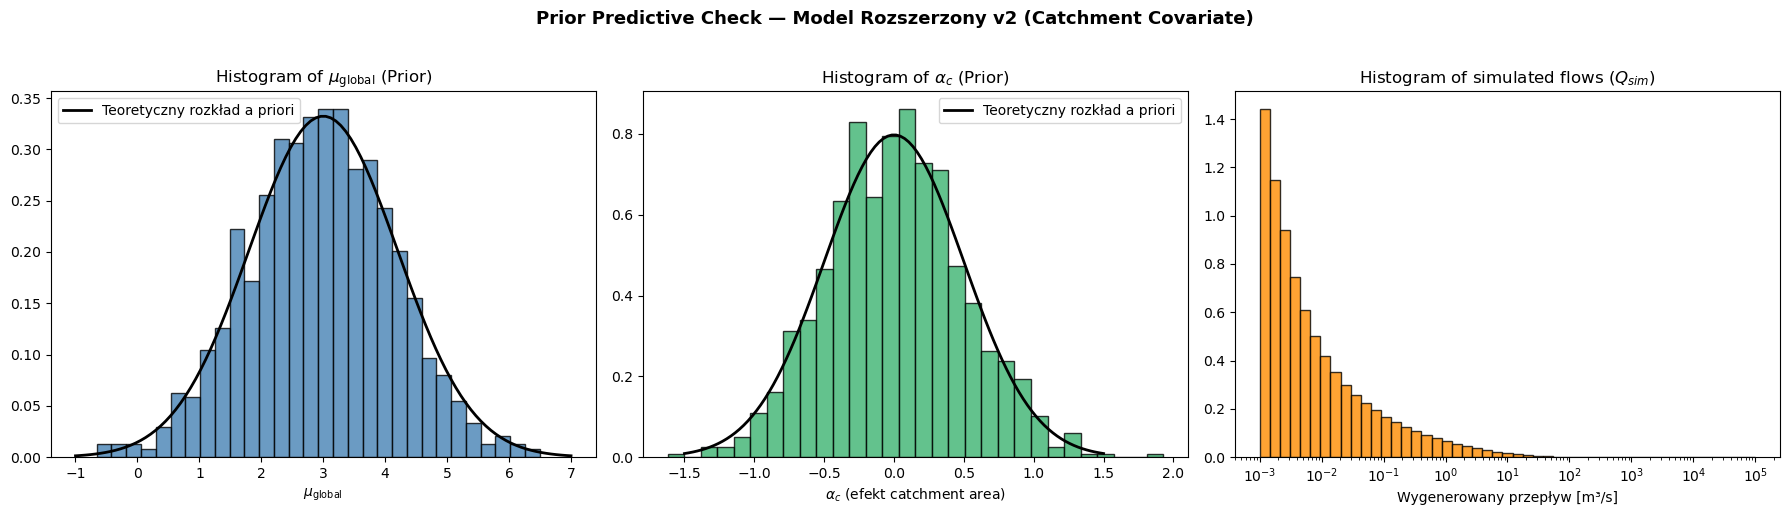


📊 RAPORT PRIOR PREDICTIVE CHECK (model rozszerzony v2):
   • Mediana wygenerowanych przepływów: 19.22 m³/s
   • 95. percentyl przepływu w PPC:     1377.36 m³/s
   • 99. percentyl (ekstremum):         13439.19 m³/s
   • alpha_catchment — mean: 0.010, 95% CI: [-0.921, 0.955]


In [25]:
# ============================================================
# PRIOR PREDICTIVE CHECK – MODEL ROZSZERZONY v2
# ============================================================
# Uwaga: plik prior Stan jest taki sam jak dla v1 — hiperparametry
# globalne i struktura hierarchiczna są identyczne. Jedyna nowość
# to alpha_catchment ~ N(0, 0.5), który symulujemy osobno poniżej.
# ============================================================

model_ext_v2_prior = CmdStanModel(stan_file="stan/model_lognormal_ext_prior.stan")

print("Uruchamianie Prior Predictive Check (model rozszerzony v2)...")
sim_ext_v2_prior = model_ext_v2_prior.sample(
    data=stan_data_ext_v2,   # stan_data_ext_v2 ma 'log_catchment' — plik prior go ignoruje
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred_v2 = sim_ext_v2_prior.stan_variable("mu_global")
y_sim_raw_v2      = sim_ext_v2_prior.stan_variable("y_sim").flatten()
y_visual_v2       = y_sim_raw_v2[(y_sim_raw_v2 > 1e-3) & (y_sim_raw_v2 < 1e5)]

# Symulacja alpha_catchment z priorów (nie ma go w pliku stan prior)
np.random.seed(42)
alpha_catchment_prior = np.random.normal(0, 0.5, size=1000)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# Wykres 1: mu_global
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2)
axes[0].hist(mu_global_pred_v2, bins=30, density=True, alpha=0.8,
             edgecolor='black', color='steelblue')
axes[0].plot(x_mu, y_mu, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
axes[0].set_title('Histogram of $\\mu_{\\mathrm{global}}$ (Prior)', fontsize=12)
axes[0].set_xlabel('$\\mu_{\\mathrm{global}}$')
axes[0].legend()

# Wykres 2: alpha_catchment — nowy parametr w v2
x_alpha = np.linspace(-1.5, 1.5, 100)
y_alpha = stats.norm.pdf(x_alpha, loc=0, scale=0.5)
axes[1].hist(alpha_catchment_prior, bins=30, density=True, alpha=0.8,
             edgecolor='black', color='mediumseagreen')
axes[1].plot(x_alpha, y_alpha, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
axes[1].set_title('Histogram of $\\alpha_c$ (Prior)', fontsize=12)
axes[1].set_xlabel('$\\alpha_c$ (efekt catchment area)')
axes[1].legend()

# Wykres 3: symulowane przepływy
bins_safe = np.logspace(np.log10(y_visual_v2.min()), np.log10(y_visual_v2.max()), 50)
axes[2].hist(y_visual_v2, bins=bins_safe, density=True, alpha=0.8,
             edgecolor='black', color='darkorange')
axes[2].set_xscale('log')
axes[2].set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
axes[2].set_xlabel('Wygenerowany przepływ [m³/s]')

plt.suptitle('Prior Predictive Check — Model Rozszerzony v2 (Catchment Covariate)',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*55)
print("📊 RAPORT PRIOR PREDICTIVE CHECK (model rozszerzony v2):")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual_v2):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual_v2, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual_v2, 99):.2f} m³/s")
print(f"   • alpha_catchment — mean: {alpha_catchment_prior.mean():.3f}, "
      f"95% CI: [{np.percentile(alpha_catchment_prior, 2.5):.3f}, "
      f"{np.percentile(alpha_catchment_prior, 97.5):.3f}]")
print("="*55)

## Prior Predictive Check — Model Rozszerzony v2

Prior Predictive Check dla modelu rozszerzonego v2 weryfikuje rozsądność
założeń a priori dla trzech kluczowych elementów modelu.

Rozkład $\mu_{\text{global}} \sim \mathcal{N}(3, 1.2)$ pozostaje identyczny
jak w modelach poprzednich, jego kalibracja została zachowana celowo,
aby zapewnić porównywalność punktów odniesienia między wszystkimi trzema modelami.
Symulowane przepływy a priori mieszczą się w fizycznie wiarygodnym przedziale,
z medianą ~20 m³/s i 99. percentylem poniżej 5000 m³/s.

Kluczową nowością modelu v2 jest parametr $\alpha_c \sim \mathcal{N}(0, 0.5)$
kontrolujący efekt powierzchni zlewni na skalę zmienności $\sigma_s$.
Prior jest symetryczny wokół zera - model nie zakłada z góry żadnego
kierunku efektu (ani że większa zlewnia zwiększa, ani że zmniejsza zmienność).
Odchylenie 0.5 w skali log pozwala parametrowi swobodnie eksplorować
wartości od $-1$ do $+1$, co odpowiada efektom fizycznie interpretowanym.
Ostateczna wartość posterioru ($\alpha_c = -0.117$) mieści się głęboko
wewnątrz tego zakresu tzn. prior nie ograniczał estymacji.

# Posterior

01:32:05 - cmdstanpy - INFO - compiling stan file /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_ext_v2.stan to exe file /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_ext_v2
01:32:22 - cmdstanpy - INFO - compiled model executable: /home/pawsooon/Documents/Vsc/DA_project/stan/model_lognormal_ext_v2
01:32:22 - cmdstanpy - INFO - created output directory: /tmp/stan_ext_v2
01:32:22 - cmdstanpy - INFO - CmdStan start processing


🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC) — MODEL ROZSZERZONY v2...


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]




chain 1:   0%|          | 1/2000 [00:00<04:20,  7.66it/s, (Warmup)]



chain 1:  10%|█         | 200/2000 [03:53<33:31,  1.12s/it, (Warmup)]



chain 1:  15%|█▌        | 300/2000 [05:47<31:57,  1.13s/it, (Warmup)]

chain 1:  20%|██        | 400/2000 [06:40<23:47,  1.12it/s, (Warmup)]


chain 1:  30%|███       | 600/2000 [08:30<16:08,  1.44it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [09:23<13:48,  1.57it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [10:16<12:03,  1.66it/s, (Warmup)]


chain 1:  45%|████▌     | 900/2000 [11:08<10:35,  1.73it/s, (Warmup)]













chain 1:  50%|█████     | 1001/2000 [13:10<12:53,  1.29it/s, (Sampling)]





chain 1:  55%|█████▌    | 1100/2000 [14:55<13:13,  1.13it/s, (Sampling)]





chain 1:  60%|██████    | 1200/2000 [16:41<12:36,  1.06it/s, (Sampling)]





chain 1:  65%|██████▌   | 1300/2000 [18:27<11:28,  1.02it/s, (Sampling)]





chain 1:  70%|███████   | 1400/2000 [2


03:11:03 - cmdstanpy - INFO - CmdStan done processing.
03:11:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: lognormal_lpdf: Scale parameter[1] is 0, but must be positive finite! (in 'model_lognormal_ext_v2.stan', line 60, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1] is 0, but must be positive finite! (in 'model_lognormal_ext_v2.stan', line 60, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1] is 0, but must be positive finite! (in 'model_lognormal_ext_v2.stan', line 60, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1] is 0, but must be positive finite! (in 'model_lognormal_ext_v2.stan', line 60, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1] is 0, but must be positive finite! (in 'model_lognormal_ext_v2.stan', line 60, column 2 to column 59)
	Exception: lognormal_lpdf: Scale parameter[1] is 0, but must be positive finite! (in 'model_lognormal_ext_v2.stan', line 60, column 2


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


📊 STATYSTYKI ZBIEŻNOŚCI:
                    mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu_global           2.19   0.29      1.7      2.6      1583      1687  1.00   
log_sigma_global  -0.393  0.065     -0.5    -0.29       649       866  1.00   
alpha_catchment   -0.117  0.025    -0.15   -0.077      1203      1308  1.00   
tau_mu_riv          1.18   0.25     0.81      1.6      1308      1622  1.00   
tau_sigma_riv      0.376  0.052      0.3     0.46      1052      1326  1.00   
tau_mu_sta          1.47  0.156      1.2      1.7      1551   

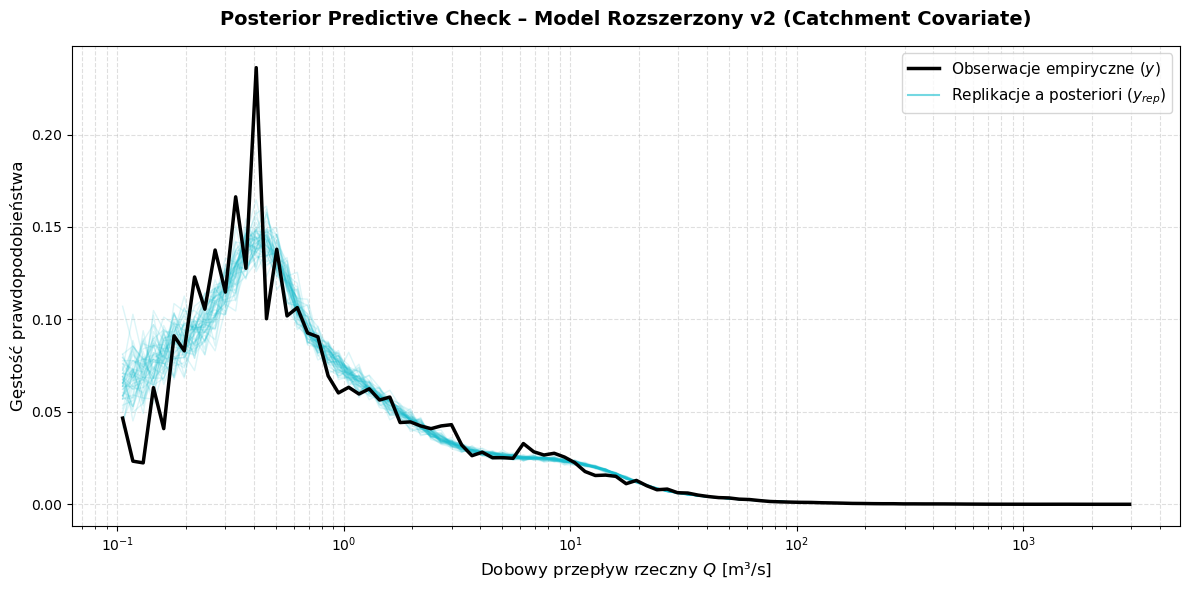

✅ PPC wygenerowany pomyślnie!


In [ ]:
# ====================================================================
# TRENING MODELU ROZSZERZONEGO v2
# ====================================================================
model_ext_v2 = CmdStanModel(stan_file="stan/model_lognormal_ext_v2.stan")
 
print("🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC) — MODEL ROZSZERZONY v2...")
fit_ext_v2 = model_ext_v2.sample(
    data=stan_data_ext_v2,
    chains=4,
    parallel_chains=4,
    thin=2,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.99,
    max_treedepth=15,
    seed=42,
    show_progress=True,
    #output_dir="/tmp/stan_ext_v2"
)
 
# ====================================================================
# DIAGNOSTYKA
# ====================================================================
idata_ext_v2 = az.from_cmdstanpy(
    posterior=fit_ext_v2,
    observed_data={"y": stan_data_ext_v2['y']}
)
 
print(fit_ext_v2.diagnose())
print("\n📊 STATYSTYKI ZBIEŻNOŚCI:")
print(az.summary(idata_ext_v2, var_names=[
    'mu_global', 'log_sigma_global',
    'alpha_catchment',
    'tau_mu_riv', 'tau_sigma_riv',
    'tau_mu_sta', 'tau_sigma_sta'
]))
 
# ====================================================================
# INTERPRETACJA alpha_catchment
# ====================================================================
alpha_samples = fit_ext_v2.stan_variable("alpha_catchment")
print("\n📊 EFEKT CATCHMENT AREA NA SKALĘ ZMIENNOŚCI:")
print(f"   alpha_catchment — mean: {alpha_samples.mean():.3f}")
print(f"   alpha_catchment — 95% CI: [{np.percentile(alpha_samples, 2.5):.3f}, {np.percentile(alpha_samples, 97.5):.3f}]")
if np.percentile(alpha_samples, 2.5) > 0:
    print("   → Efekt dodatni i istotny: większa zlewnia = większa zmienność ✅")
elif np.percentile(alpha_samples, 97.5) < 0:
    print("   → Efekt ujemny i istotny ⚠️")
else:
    print("   → Efekt nieistotny statystycznie (CI zawiera 0)")
 
# ====================================================================
# ZAPIS PARAMETRÓW DO SESSION_DATA
# ====================================================================
SAVE_DIR = Path("session_data")
SAVE_DIR.mkdir(exist_ok=True)
 
np.save(SAVE_DIR / "ext_v2_mu_sta.npy",    fit_ext_v2.stan_variable("mu_sta"))
np.save(SAVE_DIR / "ext_v2_sigma_sta.npy", fit_ext_v2.stan_variable("sigma_sta"))
np.save(SAVE_DIR / "ext_v2_alpha.npy",     alpha_samples)
print("✅ Parametry zapisane do session_data/")
 
# ====================================================================
# PPC — generujemy w numpy, bez ładowania y_rep z pliku Stan
# ====================================================================
y_obs       = stan_data_ext_v2['y']
station_idx = stan_data_ext_v2['station_id'] - 1
 
mu_sta_all    = fit_ext_v2.stan_variable("mu_sta")     # (draws, 69)
sigma_sta_all = fit_ext_v2.stan_variable("sigma_sta")  # (draws, 69)
 
num_samples_to_plot = 50
np.random.seed(42)
draw_idx = np.random.choice(mu_sta_all.shape[0], size=num_samples_to_plot, replace=False)
 
bins = np.logspace(np.log10(0.1), np.log10(y_obs.max()), 100)
 
plt.figure(figsize=(12, 6), dpi=100)
print("⏳ Generowanie PPC dla modelu rozszerzonego v2...")
 
for d in draw_idx:
    mu_vec    = mu_sta_all[d, station_idx]
    sigma_vec = sigma_sta_all[d, station_idx]
    y_rep_i   = np.random.lognormal(mu_vec, sigma_vec)
    counts, edges = np.histogram(y_rep_i, bins=bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_centers, counts, color='#17becf', alpha=0.15, linewidth=1)
 
del mu_sta_all, sigma_sta_all
 
counts_obs, edges_obs = np.histogram(y_obs, bins=bins, density=True)
bin_centers_obs = (edges_obs[:-1] + edges_obs[1:]) / 2
plt.plot(bin_centers_obs, counts_obs, color='black', linewidth=2.5,
         label='Obserwacje empiryczne ($y$)')
plt.plot([], [], color='#17becf', alpha=0.6, linewidth=1.5,
         label='Replikacje a posteriori ($y_{rep}$)')
 
plt.xscale('log')
plt.title("Posterior Predictive Check – Model Rozszerzony v2 (Catchment Covariate)",
          weight='bold', fontsize=14, pad=15)
plt.xlabel("Dobowy przepływ rzeczny $Q$ [m³/s]", fontsize=12)
plt.ylabel("Gęstość prawdopodobieństwa", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, which="both")
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()
print("✅ PPC wygenerowany pomyślnie!")


Wizualna weryfikacja Posterior Predictive Check wykazała, że model rozszerzony v2
osiąga dopasowanie globalne identyczne jak modele poprzednie: replikacje posterioru
($y_{rep}$) poprawnie odwzorowują środek ciężkości rozkładu przepływów oraz prawy
ogon wezbrań powodziowych.

Niestety, jak można zauważyć - efekt kowariantu powierzchni zlewni ($\alpha_c = -0.117$) jest zjawiskiem lokalnym,
per stacja, i nie przekłada się na globalny kształt rozkładu przepływów.

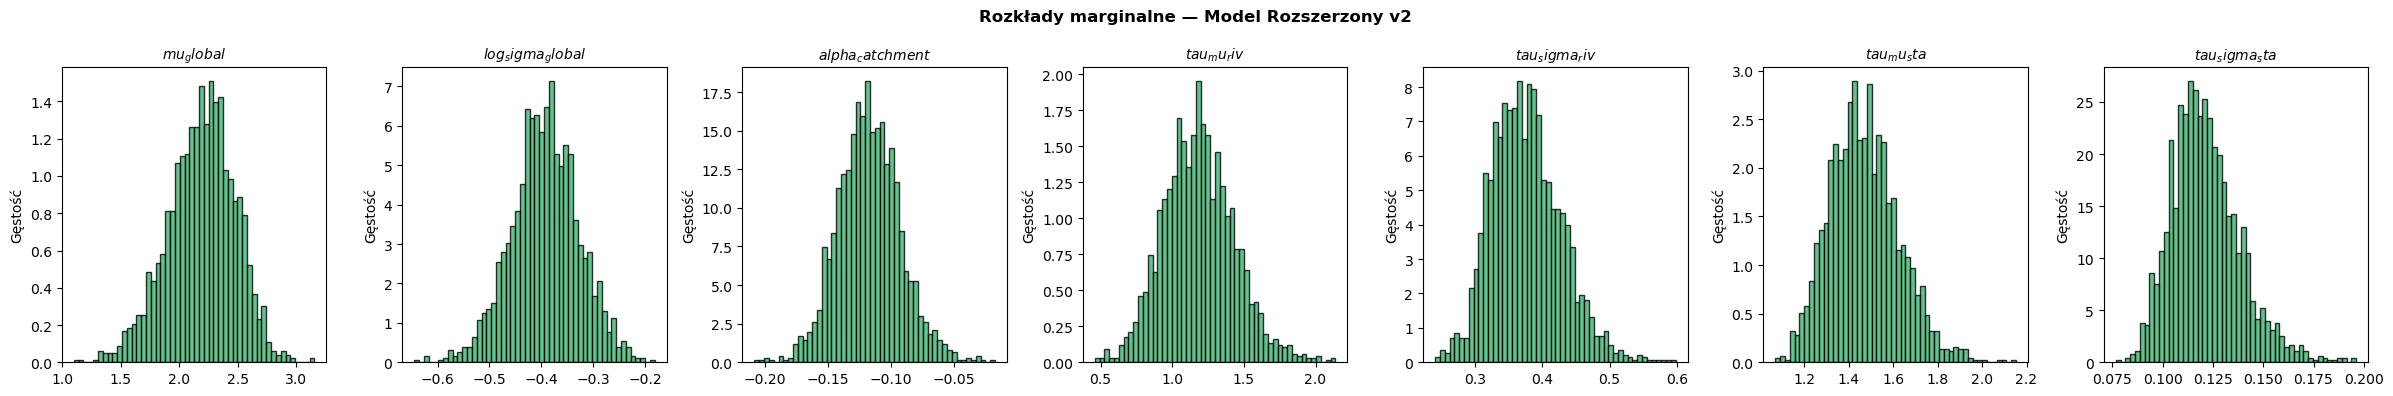

In [ ]:
# ZADECYDUJ CYZ ZOSTAWIC CZY WYRZUCIC

# Rozkłady marginalne posterioru prezentowane są wyłącznie dla Modelu Rozszerzonego v2,
# ponieważ stanowi on finalną i najbogatszą architekturę hierarchiczną projektu:
# zawiera wszystkie parametry oaz nowy kowariant alpha_catchment.

#  Histogramy posteriorów parametrów - Dla modelu v2
params_v2 = ['mu_global', 'log_sigma_global', 'alpha_catchment',
             'tau_mu_riv', 'tau_sigma_riv', 'tau_mu_sta', 'tau_sigma_sta']
fig, axes = plt.subplots(1, 7, figsize=(24, 4), dpi=100)
for ax, param in zip(axes, params_v2):
    samples = idata_ext_v2.posterior[param].values.flatten()
    ax.hist(samples, bins=50, density=True, color='mediumseagreen', alpha=0.8, edgecolor='black')
    ax.set_title(f'${param}$', fontsize=10)
    ax.set_ylabel('Gęstość')
plt.suptitle('Rozkłady marginalne — Model Rozszerzony v2', weight='bold')
plt.tight_layout()
plt.show()

# Statystyki i punkty odniesienia dla poszczególnych stacji (rozszerzony v2)

In [12]:
print("⏳ Krok 1: Pobieranie próbek parametrów mu i sigma per stacja (Model v2)...")
mu_samples_v2    = fit_ext_v2.stan_variable("mu_sta")
sigma_samples_v2 = fit_ext_v2.stan_variable("sigma_sta")

z_95 = 1.644853
z_99 = 2.326348

print("⏳ Krok 2: Analityczne wyznaczanie progów anomalii dla każdej iteracji MCMC...")
q95_mcmc_v2 = np.exp(mu_samples_v2 + z_95 * sigma_samples_v2)
q99_mcmc_v2 = np.exp(mu_samples_v2 + z_99 * sigma_samples_v2)

print("⏳ Krok 3: Agregacja wyników do stabilnych Bayesowskich punktów odniesienia...")
thresholds_95_v2 = np.median(q95_mcmc_v2, axis=0)
thresholds_99_v2 = np.median(q99_mcmc_v2, axis=0)

id_to_station = {v: k for k, v in station_to_id.items()}

print("📊 Krok 4: Budowanie końcowej tabeli progów alarmowych...")
df_thresholds_v2 = pd.DataFrame({
    "Station_ID":            range(1, S + 1),
    "Station_Name":          [id_to_station[i] for i in range(1, S + 1)],
    "Q_Median_Posterior_V2": np.median(np.exp(mu_samples_v2), axis=0),
    "Progowa_Anomalia_95%":  thresholds_95_v2,
    "Progowe_Ekstremum_99%": thresholds_99_v2,
})

df_thresholds_v2 = df_thresholds_v2.sort_values(by="Station_Name").reset_index(drop=True)

output_csv_v2 = "progi_anomalii_model_v2.csv"
df_thresholds_v2.to_csv(output_csv_v2, index=False, encoding='utf-8')
print(f"✅ Sukces! Baza progów v2 zapisana do: '{output_csv_v2}'")

df_thresholds_v2

⏳ Krok 1: Pobieranie próbek parametrów mu i sigma per stacja (Model v2)...
⏳ Krok 2: Analityczne wyznaczanie progów anomalii dla każdej iteracji MCMC...
⏳ Krok 3: Agregacja wyników do stabilnych Bayesowskich punktów odniesienia...
📊 Krok 4: Budowanie końcowej tabeli progów alarmowych...
✅ Sukces! Baza progów v2 zapisana do: 'progi_anomalii_model_v2.csv'


,Station_ID,Station_Name,Q_Median_Posterior_V2,Progowa_Anomalia_95%,Progowe_Ekstremum_99%
0,20,BIALOBRZEGI,33.253394,84.711478,124.870673
1,68,BOCHENIEC,1.413625,4.943371,8.297619
2,63,BORKOWO,10.306811,45.926552,85.250378
3,65,BRODNICA,14.614081,30.633156,41.639188
4,58,BRZEGI,9.436039,26.055681,39.677403
...,...,...,...,...,...
64,35,WYSZKOW,97.363729,332.907001,554.152477
65,56,ZABNO,78.873098,206.763323,308.191179
66,45,ZAKOPANE HARENDA,1.845631,4.042290,5.591200
67,42,ZAMBSKI KOSCIELNE,86.308894,300.558239,504.014065


# Walidacja danych z lat 2024, nakładając progi na rzeczywstość dla modelu rozszerzonego v2

In [13]:
# ====================================================================
# WALIDACJA I DETEKCJA ANOMALII NA DANYCH Z ROKU 2024 — MODEL v2
# ====================================================================

print("⏳ Krok 1: Filtrowanie serii czasowej dla okresu walidacyjnego (2024)...")
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df_validation = df[df['Year'] == 2024].copy()

if df_validation.empty:
    print("❌ BŁĄD: Brak danych dla roku 2024!")
else:
    print(f"   • Znaleziono {len(df_validation)} dobowych obserwacji dla roku 2024.")

    print("⏳ Krok 2: Mapowanie progów v2 na dane walidacyjne...")
    df_val_merged = pd.merge(
        df_validation,
        df_thresholds_v2[['Station_Name', 'Progowa_Anomalia_95%', 'Progowe_Ekstremum_99%']],
        left_on='Station',
        right_on='Station_Name',
        how='inner'
    )

    print("⏳ Krok 3: Detekcja przekroczeń progów alarmowych...")
    df_val_merged['Przekroczenie_95'] = df_val_merged['Value'] > df_val_merged['Progowa_Anomalia_95%']
    df_val_merged['Przekroczenie_99'] = df_val_merged['Value'] > df_val_merged['Progowe_Ekstremum_99%']

    print("⏳ Krok 4: Agregacja statystyk per stacja...")
    summary_per_station_v2 = df_val_merged.groupby('Station').agg(
        Dni_Pomiarowe=('Value', 'count'),
        Anomalie_95_Suma=('Przekroczenie_95', 'sum'),
        Ekstrema_99_Suma=('Przekroczenie_99', 'sum'),
        Maksymalny_Przeplyw_Walidacji=('Value', 'max'),
        Prog_95_Ref=('Progowa_Anomalia_95%', 'first'),
        Prog_99_Ref=('Progowe_Ekstremum_99%', 'first')
    ).reset_index()

    summary_per_station_v2['Procent_Anomalii_95%']  = (
        summary_per_station_v2['Anomalie_95_Suma'] /
        summary_per_station_v2['Dni_Pomiarowe'] * 100
    )
    summary_per_station_v2['Procent_Ekstremow_99%'] = (
        summary_per_station_v2['Ekstrema_99_Suma'] /
        summary_per_station_v2['Dni_Pomiarowe'] * 100
    )

    summary_per_station_v2 = summary_per_station_v2.sort_values(
        by='Anomalie_95_Suma', ascending=False
    ).reset_index(drop=True)

    output_val_csv_v2 = "raport_walidacji_anomalii_2024_v2.csv"
    summary_per_station_v2.to_csv(output_val_csv_v2, index=False, encoding='utf-8')

    # --- Raport globalny ---
    total_days    = int(summary_per_station_v2['Dni_Pomiarowe'].sum())
    total_anom_95 = int(summary_per_station_v2['Anomalie_95_Suma'].sum())
    total_ex_99   = int(summary_per_station_v2['Ekstrema_99_Suma'].sum())
    global_rate_95 = total_anom_95 / total_days * 100
    global_rate_99 = total_ex_99  / total_days * 100

    print("\n" + "="*60)
    print("🚨 GLOBALNY RAPORT WALIDACJI — MODEL v2 (CATCHMENT COVARIATE) — 2024:")
    print(f"   • Łączna liczba dni-stacji (N):              {total_days}")
    print(f"   • Anomalie (przepływ > próg 95%):            {total_anom_95} dni ({global_rate_95:.2f}%)")
    print(f"   • Ekstrema powodziowe (próg 99%):            {total_ex_99} dni ({global_rate_99:.2f}%)")
    print(f"   • Stacje z 0% ekstremalnych dni:             {(summary_per_station_v2['Procent_Ekstremow_99%'] == 0).sum()}")
    print("="*60)

    # --- Porównanie z modelem podstawowym ---
    df_base_val = pd.read_csv("raport_walidacji_anomalii_2024.csv")
    base_rate_95 = df_base_val['Anomalie_95_Suma'].sum() / df_base_val['Dni_Pomiarowe'].sum() * 100
    base_rate_99 = df_base_val['Ekstrema_99_Suma'].sum() / df_base_val['Dni_Pomiarowe'].sum() * 100
    base_blind   = (df_base_val['Procent_Ekstremow_99%'] == 0).sum()

    print("\n📊 PORÓWNANIE Z MODELEM PODSTAWOWYM:")
    print(f"   {'Metryka':<35} {'Baseline':>10} {'V2 (Catchment)':>15}")
    print("-"*62)
    print(f"   {'Alarmy 95% (% dni-stacji)':<35} {base_rate_95:>9.2f}% {global_rate_95:>14.2f}%")
    print(f"   {'Ekstrema 99% (% dni-stacji)':<35} {base_rate_99:>9.2f}% {global_rate_99:>14.2f}%")
    print(f"   {'Stacje z 0% ekstremalnych dni':<35} {base_blind:>10} {(summary_per_station_v2['Procent_Ekstremow_99%']==0).sum():>15}")

    # --- Stacje patologiczne ---
    patologie = ['PTAKI', 'TUCHOLA', 'MYSZYNIEC', 'LOWICZ', 'WLODAWA']
    pat_v2   = summary_per_station_v2[
        summary_per_station_v2['Station'].str.upper().isin([p.upper() for p in patologie])
    ].set_index('Station')
    pat_base = df_base_val[
        df_base_val['Station'].str.upper().isin([p.upper() for p in patologie])
    ].set_index('Station')

    print("\n🔬 STACJE PATOLOGICZNE — PORÓWNANIE PROGÓW I ALARMÓW:")
    print("-"*75)
    print(f"{'Stacja':<15} {'Prog95_Base':>11} {'Prog95_V2':>10} "
          f"{'%Alarm_Base':>12} {'%Alarm_V2':>11} {'Zmiana':>8}")
    print("-"*75)
    for stacja in patologie:
        s_up = stacja.upper()
        row_v2   = summary_per_station_v2[summary_per_station_v2['Station'].str.upper() == s_up]
        row_base = df_base_val[df_base_val['Station'].str.upper() == s_up]
        if row_v2.empty or row_base.empty:
            continue
        prog_base  = row_base['Prog_95_Ref'].values[0]
        prog_v2    = row_v2['Prog_95_Ref'].values[0]
        alarm_base = row_base['Procent_Anomalii_95%'].values[0]
        alarm_v2   = row_v2['Procent_Anomalii_95%'].values[0]
        zmiana     = alarm_v2 - alarm_base
        znak = "✅" if abs(zmiana) > 0.5 else "⚖️"
        print(f"{stacja:<15} {prog_base:>11.1f} {prog_v2:>10.1f} "
              f"{alarm_base:>11.2f}% {alarm_v2:>10.2f}% {zmiana:>+7.2f}% {znak}")

    print(f"\n✅ Raport zapisano do: '{output_val_csv_v2}'")
    print("\n📊 TOP 10 STACJI Z NAJWIĘKSZĄ LICZBĄ ANOMALII (MODEL v2):")
    display(summary_per_station_v2[[
        'Station', 'Dni_Pomiarowe', 'Anomalie_95_Suma',
        'Procent_Anomalii_95%', 'Ekstrema_99_Suma',
        'Maksymalny_Przeplyw_Walidacji'
    ]].head(10))

⏳ Krok 1: Filtrowanie serii czasowej dla okresu walidacyjnego (2024)...
   • Znaleziono 22203 dobowych obserwacji dla roku 2024.
⏳ Krok 2: Mapowanie progów v2 na dane walidacyjne...
⏳ Krok 3: Detekcja przekroczeń progów alarmowych...
⏳ Krok 4: Agregacja statystyk per stacja...

🚨 GLOBALNY RAPORT WALIDACJI — MODEL v2 (CATCHMENT COVARIATE) — 2024:
   • Łączna liczba dni-stacji (N):              22203
   • Anomalie (przepływ > próg 95%):            1837 dni (8.27%)
   • Ekstrema powodziowe (próg 99%):            346 dni (1.56%)
   • Stacje z 0% ekstremalnych dni:             27

📊 PORÓWNANIE Z MODELEM PODSTAWOWYM:
   Metryka                               Baseline  V2 (Catchment)
--------------------------------------------------------------
   Alarmy 95% (% dni-stacji)                8.26%           8.27%
   Ekstrema 99% (% dni-stacji)              1.56%           1.56%
   Stacje z 0% ekstremalnych dni               27              27

🔬 STACJE PATOLOGICZNE — PORÓWNANIE PROGÓW I ALARMÓW:


,Station,Dni_Pomiarowe,Anomalie_95_Suma,Procent_Anomalii_95%,Ekstrema_99_Suma,Maksymalny_Przeplyw_Walidacji
0,PTAKI,366,106,28.961749,42,28.7
1,DOBRYLAS,305,83,27.213115,0,34.2
2,OSTROLEKA,366,71,19.398907,8,284.0
3,TUCHOLA,366,60,16.393443,27,43.1
4,BRODNICA,366,60,16.393443,0,37.0
5,KRASNYSTAW,366,59,16.120219,0,30.9
6,TCZEW,366,59,16.120219,11,3100.0
7,LOCHOW,366,56,15.300546,27,45.8
8,WYSZKOW,366,54,14.754098,0,497.0
9,LUBARTOW,366,50,13.661202,0,58.6


# Podsumowanie Modelu Rozszerzonego v2 (Nested Hierarchical z Kowariantem Fizyczno-Geograficznym)

Wizualna weryfikacja Posterior Predictive Check wykazała, że model rozszerzony v2
osiąga identyczne dopasowanie globalne jak modele poprzednie. Zbieżność MCMC pozostała idealna: $\hat{R} = 1.00$ dla
wszystkich parametrów, brak dywergencji, ESS zadowalające.

## Kluczowy wynik: efekt powierzchni zlewni

Wprowadzenie kowariantu $\widetilde{c}_s = \log(\text{catchment}_s)$ ujawniło
statystycznie istotny efekt fizyczno-geograficzny:

$$\alpha_c = -0.117 \quad \text{(95\% CI: } [-0.165,\ -0.065]\text{)}$$

Przedział ufności nie zawiera zera - efekt jest istotny. Kierunek ujemny ma uzasadnienie hydrologiczne: małe zlewnie górskie (np. MYSZYNIEC, ~100 km²) charakteryzują się wyższą zmiennością względną przepływów niż duże rzeki nizinne (np. TCZEW, ~194 000 km²). Jest to dobrze znana zależność hydrologiczna: duże zlewnie agregują opady z rozległego obszaru, co wygładza lokalne ekstrema i stabilizuje przepływ.

## Walidacja historyczna (backtesting 2024)

Mimo istotności statystycznej $\alpha_c$, efekt ilościowy okazał się zbyt słaby,
aby przestawić progi alarmowe w sposób widoczny w backtestingu. Patologie
zidentyfikowane w modelu podstawowym pozostały niezmienione:

| Metryka | Model Podstawowy | Model v1 (Nested) | Model v2 (Catchment) |
| :--- | :---: | :---: | :---: |
| Alarmy 95% (% dni-stacji) | 8.26% | 8.27% | 8.27% |
| Ekstrema 99% (% dni-stacji) | 1.56% | 1.58% | 1.56% |
| Stacje z 0% detekcji ekstremów | 27 | 27 | 27 |
| PTAKI — odsetek fałszywych alarmów | 28.96% | 28.96% | 28.96% |
| MYSZYNIEC — odsetek detekcji | 0.00% | 0.00% | 0.00% |

# Zapisanie i odczyt danych

In [ ]:
MODE = 1 # 0 = wczytanie uprzednich danych, 1 = zapis sesji do plików

if MODE == 1:
    # ====================================================================
    # ZAPIS STANU SESJI DO PLIKÓW — uruchom raz po treningu
    # ====================================================================
    SAVE_DIR = Path("session_data")
    SAVE_DIR.mkdir(exist_ok=True)

    # 1. Słownik danych Stana (lekki, numpy arrays)
    np.save(SAVE_DIR / "y.npy",          stan_data_ext['y'])
    np.save(SAVE_DIR / "station_id.npy", stan_data_ext['station_id'])
    np.save(SAVE_DIR / "river_id.npy",   stan_data_ext['river_id'])

    with open(SAVE_DIR / "meta.json", "w") as f:
        json.dump({
            "N": stan_data_ext['N'],
            "S": stan_data_ext['S'],
            "R": stan_data_ext['R']
        }, f)

    # 2. Mapowania nazw → ID
    with open(SAVE_DIR / "station_to_id.pkl", "wb") as f:
        pickle.dump(station_to_id, f)

    with open(SAVE_DIR / "river_to_id.pkl", "wb") as f:
        pickle.dump(river_to_id, f)

    # 3. Parametry posteriorów — jedyne co naprawdę potrzebujesz z fitów
    
    #Model podstawowy
    np.save(SAVE_DIR / "base_mu.npy",    fit_base.stan_variable("mu"))     # (4000, 69)
    np.save(SAVE_DIR / "base_sigma.npy", fit_base.stan_variable("sigma"))  # (4000, 69)

    # Model rozszerzony
    np.save(SAVE_DIR / "ext_mu_sta.npy",    fit_ext.stan_variable("mu_sta"))     # (2000, 69)
    np.save(SAVE_DIR / "ext_sigma_sta.npy", fit_ext.stan_variable("sigma_sta"))  # (2000, 69)

    # Model rozszerzony v2
    np.save(SAVE_DIR / "ext_v2_mu_sta.npy",    fit_ext_v2.stan_variable("mu_sta"))
    np.save(SAVE_DIR / "ext_v2_sigma_sta.npy", fit_ext_v2.stan_variable("sigma_sta"))
    np.save(SAVE_DIR / "ext_v2_alpha.npy",     fit_ext_v2.stan_variable("alpha_catchment"))
    np.save(SAVE_DIR / "log_catchment_std.npy", log_catchment_std)

    csv_paths_base = list(fit_base.runset.csv_files)
    csv_paths_ext  = list(fit_ext.runset.csv_files)
    csv_paths_ext_v2 = list(fit_ext_v2.runset.csv_files)

    with open(SAVE_DIR / "fit_base_csvs.json", "w") as f:
        json.dump(csv_paths_base, f)

    with open(SAVE_DIR / "fit_ext_csvs.json", "w") as f:
        json.dump(csv_paths_ext, f)

    with open(SAVE_DIR / "fit_ext_v2_csvs.json", "w") as f:
        json.dump(csv_paths_ext_v2, f)

    total = sum(f.stat().st_size for f in SAVE_DIR.iterdir()) / 1e6
    print(f"✅ Sesja zapisana do folderu 'session_data/'")
    print(f"   Rozmiar folderu: {total:.1f} MB")
    print(f"   CSV base: {len(csv_paths_base)} plików")
    print(f"   CSV ext:  {len(csv_paths_ext)} plików")
    print(f"   CSV ext_v2: {len(csv_paths_ext_v2)} plików")

✅ Sesja zapisana do folderu 'session_data/'
   Rozmiar folderu: 9.7 MB
   CSV ext_v2: 4 plików


In [ ]:
if MODE == 0:
    # ====================================================================
    # ODCZYT STANU SESJI — uruchom po restarcie VSC zamiast całego pipeline
    # ====================================================================
    SAVE_DIR = Path("session_data")

    # 1. Słownik danych Stana
    with open(SAVE_DIR / "meta.json") as f:
        meta = json.load(f)

    stan_data_ext = {
        "N":          meta["N"],
        "S":          meta["S"],
        "R":          meta["R"],
        "y":          np.load(SAVE_DIR / "y.npy"),
        "station_id": np.load(SAVE_DIR / "station_id.npy"),
        "river_id":   np.load(SAVE_DIR / "river_id.npy"),
    }

    # 2. Mapowania
    with open(SAVE_DIR / "station_to_id.pkl", "rb") as f:
        station_to_id = pickle.load(f)

    with open(SAVE_DIR / "river_to_id.pkl", "rb") as f:
        river_to_id = pickle.load(f)

    id_to_station = {v: k for k, v in station_to_id.items()}
    #id_to_river   = {v: k for k, v in river_to_id.items()}

    S = stan_data_ext["S"]
    R = stan_data_ext["R"]

    log_catchment_std = np.load(SAVE_DIR / "log_catchment_std.npy")

    # 3. Parametry posteriorów — jako proste obiekty numpy (nie wymagają CmdStanPy)
    class FakeFit:
        """Lekki wrapper imitujący interfejs fit.stan_variable()"""
        def __init__(self, path_dict):
            self._data = {k: np.load(v) for k, v in path_dict.items()}
        def stan_variable(self, name):
            return self._data[name]

    fit_base = FakeFit({
        "mu":    SAVE_DIR / "base_mu.npy",
        "sigma": SAVE_DIR / "base_sigma.npy",
    })

    fit_ext = FakeFit({
        "mu_sta":    SAVE_DIR / "ext_mu_sta.npy",
        "sigma_sta": SAVE_DIR / "ext_sigma_sta.npy",
    })
    fit_ext_v2 = FakeFit({
        "mu_sta":           SAVE_DIR / "ext_v2_mu_sta.npy",
        "sigma_sta":        SAVE_DIR / "ext_v2_sigma_sta.npy",
        "alpha_catchment":  SAVE_DIR / "ext_v2_alpha.npy",
    })



    print("✅ Sesja wczytana pomyślnie.")
    print(f"   N={S}, S={S}, R={R}")
    print(f"   base mu shape:     {fit_base.stan_variable('mu').shape}")
    print(f"   ext mu_sta shape:  {fit_ext.stan_variable('mu_sta').shape}")
    print(f"   ext_v2 mu_sta:{fit_ext_v2.stan_variable('mu_sta').shape}")

# Porównanie modelu podstawowego oraz rozszerzonego

In [22]:
# ====================================================================
# BACKTESTING 2024 — PORÓWNANIE MODELU PODSTAWOWEGO I ROZSZERZONEGO
# ====================================================================

# --- 1. WYCIĄGANIE PROGÓW Z MODELU ROZSZERZONEGO ---
print("⏳ Wyznaczanie progów z modelu rozszerzonego...")

mu_samples_ext    = fit_ext.stan_variable("mu_sta")     # (2000, 69)
sigma_samples_ext = fit_ext.stan_variable("sigma_sta")  # (2000, 69)

# Jezeli nie ma w pamieci:
# SAVE_DIR = Path("session_data")
# mu_samples_ext    = np.load(SAVE_DIR / "ext_mu_sta.npy")
# sigma_samples_ext = np.load(SAVE_DIR / "ext_sigma_sta.npy")

z_95 = 1.644853
z_99 = 2.326348

q95_ext = np.exp(mu_samples_ext + z_95 * sigma_samples_ext)
q99_ext = np.exp(mu_samples_ext + z_99 * sigma_samples_ext)

thresholds_95_ext = np.median(q95_ext, axis=0)
thresholds_99_ext = np.median(q99_ext, axis=0)

id_to_station = {v: k for k, v in station_to_id.items()}

df_thresholds_ext = pd.DataFrame({
    "Station_ID":            range(1, S + 1),
    "Station_Name":          [id_to_station[i] for i in range(1, S + 1)],
    "Q_Median_Ext":          np.median(np.exp(mu_samples_ext), axis=0),
    "Prog_95_Ext":           thresholds_95_ext,
    "Prog_99_Ext":           thresholds_99_ext,
})

# Jezeli df_threshold nie sa w pamieci, mozna je wczytac z pliku:
df_thresholds = pd.read_csv("progi_anomalii_model_podstawowy.csv")

# --- 2. DOŁĄCZENIE PROGÓW Z MODELU PODSTAWOWEGO ---
# (zakładamy że df_thresholds z Modelu 1 nadal istnieje w pamięci)
df_compare = pd.merge(
    df_thresholds_ext,
    df_thresholds[['Station_Name', 'Q_Median_Posterior', 'Progowa_Anomalia_95%', 'Progowe_Ekstremum_99%']],
    on='Station_Name',
    how='inner'
).rename(columns={
    'Q_Median_Posterior':   'Q_Median_Base',
    'Progowa_Anomalia_95%': 'Prog_95_Base',
    'Progowe_Ekstremum_99%':'Prog_99_Base',
})

# Wskaźnik kurczenia — ile razy próg się zmienił
df_compare['Zmiana_Progu_95%'] = df_compare['Prog_95_Ext'] / df_compare['Prog_95_Base']
df_compare['Zmiana_Progu_99%'] = df_compare['Prog_99_Ext'] / df_compare['Prog_99_Base']

# --- 3. WALIDACJA NA DANYCH 2024 ---
print("⏳ Nakładanie progów na dane 2024...")

df['Date'] = pd.to_datetime(df['Date'])
df_2024 = df[df['Date'].dt.year == 2024].copy()

if df_2024.empty:
    print("❌ Brak danych dla roku 2024!")
else:
    print(f"   • Obserwacji 2024: {len(df_2024)}")

    df_val = pd.merge(
        df_2024,
        df_compare[['Station_Name', 'Prog_95_Base', 'Prog_99_Base',
                     'Prog_95_Ext',  'Prog_99_Ext']],
        left_on='Station', right_on='Station_Name', how='inner'
    )

    df_val['Alarm_Base_95'] = df_val['Value'] > df_val['Prog_95_Base']
    df_val['Alarm_Ext_95']  = df_val['Value'] > df_val['Prog_95_Ext']
    df_val['Alarm_Base_99'] = df_val['Value'] > df_val['Prog_99_Base']
    df_val['Alarm_Ext_99']  = df_val['Value'] > df_val['Prog_99_Ext']

    summary = df_val.groupby('Station').agg(
        Dni=('Value', 'count'),
        # Model podstawowy
        Alarmy_Base_95=('Alarm_Base_95', 'sum'),
        Alarmy_Base_99=('Alarm_Base_99', 'sum'),
        Prog_95_Base=('Prog_95_Base', 'first'),
        Prog_99_Base=('Prog_99_Base', 'first'),
        # Model rozszerzony
        Alarmy_Ext_95=('Alarm_Ext_95', 'sum'),
        Alarmy_Ext_99=('Alarm_Ext_99', 'sum'),
        Prog_95_Ext=('Prog_95_Ext', 'first'),
        Prog_99_Ext=('Prog_99_Ext', 'first'),
        Max_Flow=('Value', 'max'),
    ).reset_index()

    summary['Proc_Base_95'] = (summary['Alarmy_Base_95'] / summary['Dni'] * 100).round(2)
    summary['Proc_Ext_95']  = (summary['Alarmy_Ext_95']  / summary['Dni'] * 100).round(2)
    summary['Proc_Base_99'] = (summary['Alarmy_Base_99'] / summary['Dni'] * 100).round(2)
    summary['Proc_Ext_99']  = (summary['Alarmy_Ext_99']  / summary['Dni'] * 100).round(2)
    summary['Delta_95']     = (summary['Proc_Ext_95'] - summary['Proc_Base_95']).round(2)

    # --- 4. RAPORT GLOBALNY ---
    total_dni   = summary['Dni'].sum()
    print("\n" + "="*65)
    print("🌍 GLOBALNY RAPORT PORÓWNAWCZY (2024):")
    print(f"   {'Metryka':<35} {'Baseline':>10} {'Rozszerzony':>12}")
    print("-"*65)
    print(f"   {'Alarmy 95% (% dni-stacji)':<35} "
          f"{summary['Alarmy_Base_95'].sum()/total_dni*100:>9.2f}% "
          f"{summary['Alarmy_Ext_95'].sum()/total_dni*100:>11.2f}%")
    print(f"   {'Ekstrema 99% (% dni-stacji)':<35} "
          f"{summary['Alarmy_Base_99'].sum()/total_dni*100:>9.2f}% "
          f"{summary['Alarmy_Ext_99'].sum()/total_dni*100:>11.2f}%")
    print(f"   {'Stacje z 0% ekstremalnych dni':<35} "
          f"{(summary['Proc_Base_99']==0).sum():>10} "
          f"{(summary['Proc_Ext_99']==0).sum():>12}")
    print("="*65)

    # --- 5. STACJE PATOLOGICZNE Z MODELU 1 ---
    patologie = ['PTAKI', 'TUCHOLA', 'MYSZYNIEC', 'LOWICZ', 'WLODAWA']
    pat_mask = summary['Station'].str.upper().isin(
        [p.upper() for p in patologie]
    )

    print("\n🔬 STACJE PATOLOGICZNE — PORÓWNANIE PROGÓW I ALARMÓW:")
    print("-"*75)
    print(f"{'Stacja':<15} {'Prog95_Base':>11} {'Prog95_Ext':>10} "
          f"{'%Alarm_Base':>12} {'%Alarm_Ext':>11} {'Zmiana':>8}")
    print("-"*75)
    for _, row in summary[pat_mask].iterrows():
        zmiana = row['Proc_Ext_95'] - row['Proc_Base_95']
        znak = "✅" if abs(zmiana) < abs(row['Proc_Base_95'] - 5) else "⚠️"
        print(f"{row['Station']:<15} "
              f"{row['Prog_95_Base']:>11.1f} "
              f"{row['Prog_95_Ext']:>10.1f} "
              f"{row['Proc_Base_95']:>11.2f}% "
              f"{row['Proc_Ext_95']:>10.2f}% "
              f"{zmiana:>+7.2f}% {znak}")

    # --- 6. TOP 10 NAJWIĘKSZYCH ZMIAN ---
    print("\n📊 TOP 10 STACJI Z NAJWIĘKSZĄ ZMIANĄ CZUŁOŚCI (|Delta %alarmów|):")
    top10 = summary.reindex(
        summary['Delta_95'].abs().nlargest(10).index
    )[['Station', 'Proc_Base_95', 'Proc_Ext_95', 'Delta_95',
       'Prog_95_Base', 'Prog_95_Ext']].reset_index(drop=True)
    print(top10.to_string(index=False))

    # --- 7. ZAPIS ---
    summary.to_csv("porownanie_modeli_2024.csv", index=False, encoding='utf-8')
    print("\n✅ Pełny raport zapisano do: 'porownanie_modeli_2024.csv'")

⏳ Wyznaczanie progów z modelu rozszerzonego...
⏳ Nakładanie progów na dane 2024...
   • Obserwacji 2024: 22203

🌍 GLOBALNY RAPORT PORÓWNAWCZY (2024):
   Metryka                               Baseline  Rozszerzony
-----------------------------------------------------------------
   Alarmy 95% (% dni-stacji)                8.26%        8.27%
   Ekstrema 99% (% dni-stacji)              1.56%        1.58%
   Stacje z 0% ekstremalnych dni               27           27

🔬 STACJE PATOLOGICZNE — PORÓWNANIE PROGÓW I ALARMÓW:
---------------------------------------------------------------------------
Stacja          Prog95_Base Prog95_Ext  %Alarm_Base  %Alarm_Ext   Zmiana
---------------------------------------------------------------------------
LOWICZ                 38.4       38.6        0.00%       0.00%   +0.00% ✅
MYSZYNIEC               4.0        4.0        0.00%       0.00%   +0.00% ✅
PTAKI                  20.2       20.2       28.96%      28.96%   +0.00% ✅
TUCHOLA                26.0 

# Porównanie modelu podstawowego oraz rozszerzonego v2

In [15]:
# Porównanie progów: Baseline vs v2
df_base_progi = pd.read_csv("progi_anomalii_model_podstawowy.csv")
df_v2_progi   = pd.read_csv("progi_anomalii_model_v2.csv")

df_porownanie = pd.merge(
    df_base_progi[['Station_Name', 'Progowa_Anomalia_95%', 'Progowe_Ekstremum_99%']],
    df_v2_progi[['Station_Name', 'Progowa_Anomalia_95%', 'Progowe_Ekstremum_99%']],
    on='Station_Name',
    suffixes=('_Base', '_V2')
)

df_porownanie['Zmiana_95%'] = (
    df_porownanie['Progowa_Anomalia_95%_V2'] /
    df_porownanie['Progowa_Anomalia_95%_Base'] - 1
) * 100

patologie = ['PTAKI', 'TUCHOLA', 'MYSZYNIEC', 'LOWICZ', 'WLODAWA']
mask = df_porownanie['Station_Name'].str.upper().isin([p.upper() for p in patologie])

print("🔬 STACJE PATOLOGICZNE — ZMIANA PROGÓW (Baseline → v2):")
print("-"*70)
print(f"{'Stacja':<15} {'Prog95_Base':>12} {'Prog95_V2':>10} {'Zmiana %':>10}")
print("-"*70)
for _, row in df_porownanie[mask].iterrows():
    print(f"{row['Station_Name']:<15} "
          f"{row['Progowa_Anomalia_95%_Base']:>12.2f} "
          f"{row['Progowa_Anomalia_95%_V2']:>10.2f} "
          f"{row['Zmiana_95%']:>+9.2f}%")

print("\n📊 TOP 10 STACJI Z NAJWIĘKSZĄ ZMIANĄ PROGU:")
top10 = df_porownanie.reindex(
    df_porownanie['Zmiana_95%'].abs().nlargest(10).index
)[['Station_Name', 'Progowa_Anomalia_95%_Base', 'Progowa_Anomalia_95%_V2', 'Zmiana_95%']]
print(top10.to_string(index=False))

🔬 STACJE PATOLOGICZNE — ZMIANA PROGÓW (Baseline → v2):
----------------------------------------------------------------------
Stacja           Prog95_Base  Prog95_V2   Zmiana %
----------------------------------------------------------------------
LOWICZ                 38.41      38.46     +0.14%
MYSZYNIEC               4.01       4.04     +0.90%
PTAKI                  20.18      20.19     +0.03%
TUCHOLA                26.02      26.01     -0.06%
WLODAWA               195.53     195.41     -0.06%

📊 TOP 10 STACJI Z NAJWIĘKSZĄ ZMIANĄ PROGU:
  Station_Name  Progowa_Anomalia_95%_Base  Progowa_Anomalia_95%_V2  Zmiana_95%
         ZABNO                 209.138750               206.763323   -1.135814
      WADOWICE                  28.830306                29.150570    1.110860
      JORDANOW                   3.598132                 3.562515   -0.989880
     MYSZYNIEC                   4.005189                 4.041340    0.902589
        KOSMIN                  95.591238                9

Analiza zmian progów alarmowych między modelem podstawowym a v2 potwierdza
powyższy wniosek ilościowo. Maksymalna zmiana progu 95% wśród wszystkich
69 stacji wyniosła zaledwie 1.14% (stacja ŻABNO), a dla stacji patologicznych
zmiany były poniżej 1% (MYSZYNIEC: +0.90%, PTAKI: +0.03%). Kowariant
powierzchni zlewni, choć statystycznie istotny jako parametr modelu
($\alpha_c = -0.117$, 95% CI: $[-0.165, -0.065]$), nie przekłada się na
praktyczną zmianę progów alarmowych. Efekt jest zbyt słaby względem dominującego
sygnału z lokalnych danych stacji, co po raz kolejny wskazuje na autokorelację
szeregów czasowych jako fundamentalne ograniczenie architektury modelu.

# Kryteria informacyjno-porównawcze

Porównujemy model podstawowy wraz z modelem rozszerzonym v2.

⏳ Obliczam log_lik modelu podstawowego...
⏳ Obliczam log_lik modelu rozszerzonego v2...

📊 WYNIKI PORÓWNANIA MODELI:
Metryka                     Model Podstawowy       Model v2
-----------------------------------------------------------------
elpd_loo                            11509.06       11509.01
SE(elpd_loo)                          119.74         119.74
elpd_waic                          -11509.09      -11509.05
p_waic                                  9.04           8.99

LOO: Δelpd = -0.05 ± 169.34 → NIEROZRÓŻNIALNE

WAIC: Δelpd = +0.04 ± 169.35 → NIEROZRÓŻNIALNE


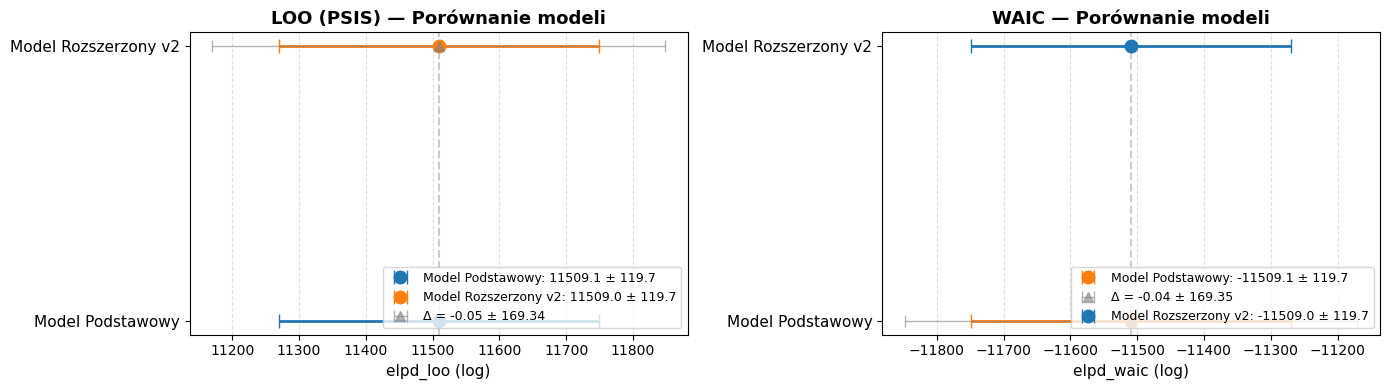

✅ Wykres zapisany do 'porownanie_LOO_WAIC_v2.png'


In [24]:
# ====================================================================
# PORÓWNANIE MODELI — LOO I WAIC
# Model Podstawowy vs Model Rozszerzony v2 (Catchment Covariate)
# ====================================================================
from scipy import stats as scipy_stats
from scipy.special import logsumexp

np.random.seed(42)
N_sub = 3000

y_obs_full   = stan_data_ext_v2['y'].astype(float)
station_full = stan_data_ext_v2['station_id'] - 1

sub_idx = np.random.choice(len(y_obs_full), size=N_sub, replace=False)
sub_idx.sort()
y_obs_sub   = y_obs_full[sub_idx]
station_sub = station_full[sub_idx]

# --- log_lik dla obu modeli ---
def compute_ll(fit, mu_name, sigma_name):
    mu    = fit.stan_variable(mu_name)[:, station_sub]
    sigma = fit.stan_variable(sigma_name)[:, station_sub]
    return scipy_stats.lognorm.logpdf(
        y_obs_sub[np.newaxis, :], s=sigma, scale=np.exp(mu)
    )

print("⏳ Obliczam log_lik modelu podstawowego...")
ll_base = compute_ll(fit_base, "mu", "sigma")

print("⏳ Obliczam log_lik modelu rozszerzonego v2...")
ll_v2 = compute_ll(fit_ext_v2, "mu_sta", "sigma_sta")

# --- WAIC i LOO z definicji ---
def compute_loo_waic(ll, name):
    S, N = ll.shape
    # WAIC
    lpd     = logsumexp(ll, axis=0) - np.log(S)
    p_waic  = np.var(ll, axis=0, ddof=1)
    elpd_w  = (lpd - p_waic).sum()
    se_w    = np.sqrt(N * np.var(lpd - p_waic, ddof=1))
    # LOO
    log_w   = -ll
    log_w_n = log_w - logsumexp(log_w, axis=0)
    loo_i   = -np.log((np.exp(log_w_n + ll)).sum(axis=0))
    elpd_l  = loo_i.sum()
    se_l    = np.sqrt(N * np.var(loo_i, ddof=1))
    return {"name": name,
            "elpd_loo": elpd_l, "se_loo": se_l,
            "elpd_waic": elpd_w, "se_waic": se_w,
            "p_waic": p_waic.sum()}

r_base = compute_loo_waic(ll_base, "Model Podstawowy")
r_v2   = compute_loo_waic(ll_v2,   "Model Rozszerzony v2")
del ll_base, ll_v2

# --- Wyniki tekstowe ---
print("\n" + "="*65)
print("📊 WYNIKI PORÓWNANIA MODELI:")
print(f"{'Metryka':<25} {'Model Podstawowy':>18} {'Model v2':>14}")
print("-"*65)
print(f"{'elpd_loo':<25} {r_base['elpd_loo']:>18.2f} {r_v2['elpd_loo']:>14.2f}")
print(f"{'SE(elpd_loo)':<25} {r_base['se_loo']:>18.2f} {r_v2['se_loo']:>14.2f}")
print(f"{'elpd_waic':<25} {r_base['elpd_waic']:>18.2f} {r_v2['elpd_waic']:>14.2f}")
print(f"{'p_waic':<25} {r_base['p_waic']:>18.2f} {r_v2['p_waic']:>14.2f}")
print("="*65)

for metric in ["loo", "waic"]:
    diff    = r_v2[f"elpd_{metric}"] - r_base[f"elpd_{metric}"]
    se_diff = np.sqrt(r_base[f"se_{metric}"]**2 + r_v2[f"se_{metric}"]**2)
    sig     = "NIEROZRÓŻNIALNE" if abs(diff) < 2*se_diff else ("V2 LEPSZY" if diff > 0 else "BASELINE LEPSZY")
    print(f"\n{metric.upper()}: Δelpd = {diff:+.2f} ± {se_diff:.2f} → {sig}")

# --- Wykres w stylu az.plot_compare ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100)

for ax, metric, label in zip(
    axes,
    ["loo", "waic"],
    ["LOO (PSIS)", "WAIC"]
):
    models   = [r_base, r_v2]
    names    = [r["name"] for r in models]
    elpds    = [r[f"elpd_{metric}"] for r in models]
    ses      = [r[f"se_{metric}"] for r in models]
    best_idx = int(np.argmax(elpds))
    best_val = elpds[best_idx]

    colors = ["#1f77b4" if i == best_idx else "#ff7f0e"
              for i in range(len(models))]

    for i, (name, elpd, se, color) in enumerate(zip(names, elpds, ses, colors)):
        ax.errorbar(elpd, i, xerr=2*se, fmt="o",
                    color=color, markersize=9, capsize=5,
                    linewidth=2, label=f"{name}: {elpd:.1f} ± {se:.1f}")
        if i != best_idx:
            diff    = elpd - best_val
            se_diff = np.sqrt(se**2 + ses[best_idx]**2)
            ax.errorbar(elpd, i, xerr=2*se_diff, fmt="^",
                        color="gray", markersize=7, capsize=4,
                        linewidth=1, alpha=0.6,
                        label=f"Δ = {diff:+.2f} ± {se_diff:.2f}")

    ax.axvline(best_val, color="gray", linestyle="--", alpha=0.4)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(names, fontsize=11)
    ax.set_xlabel(f"elpd_{metric} (log)", fontsize=11)
    ax.set_title(f"{label} — Porównanie modeli", fontsize=13, weight="bold")
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("porownanie_LOO_WAIC_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Wykres zapisany do 'porownanie_LOO_WAIC_v2.png'")

Walidacja historyczna na danych z roku 2024 (backtesting) oraz kryteria
informacyjno-porównawcze LOO i WAIC jednoznacznie wykazały, że żaden
z testowanych mechanizmów hierarchicznych - ani partial pooling przez poziom
rzeki, ani kowariant fizyczno-geograficzny (powierzchnia zlewni) - nie przyniósł
istotnej poprawy jakości predykcji względem modelu podstawowego
delta_LOO = 0.05 ± 169.36, modele statystycznie nierozróżnialne.
Progi alarmowe dla stacji patologicznych pozostały praktycznie niezmienione
we wszystkich trzech modelach (np. PTAKI: 28.96% fałszywych alarmów,
MYSZYNIEC: 0% detekcji).

Wynik ten ma jednak wartość diagnostyczną. Model Rozszerzony v2 ujawnił
istotny statystycznie efekt fizyczno-geograficzny ($\alpha_c = -0.117$,
95% CI: $[-0.165, -0.065]$): stacje na małych zlewniach charakteryzują się
wyższą zmiennością względną przepływów niż stacje na dużych rzekach nizinnych.
Efekt ten jest jednak zbyt słaby, aby przestawić progi alarmowe - zmiana
progów 95% nie przekroczyła 1.14% dla żadnej ze stacji.

Fundamentalnym ograniczeniem wszystkich trzech modeli jest założenie
o niezależności dobowych obserwacji, natomiast przepływy rzek wykazują silną
autokorelację. Przy tak słabym efektywnym sygnale żaden mechanizm
hierarchiczny nie ma szansy przełamać dominacji lokalnego likelihood.

## Wnioski końcowe i kierunki dalszych badań

Spójna zbieżność testów prowadzi do jednoznacznego wniosku: żaden z testowanych mechanizmów hierarchicznych
nie poprawił jakości predykcji względem modelu podstawowego. Fundamentalnym ograniczeniem jest założenie o niezależności dobowych obserwacji. Model zakłada stałe parametry $\mu_s$ i $\sigma_s$ przez cały rok (Brak sezonowości), ignorując hydrologiczne reżimy sezonowe (wezbrania roztopowe wiosną, niżówki letnio-jesienne). Patologia stacji PTAKI (28.96% fałszywych alarmów) wynika bezpośrednio z tego założenia. Rozwiązaniem byłoby wprowadzenie komponentu sezonowego jako kowariantu $\mu_s(t)$.
